In [1]:
# --- Сервісні підключення та команди ---

import pandas as pd
import numpy as np
import os
import re
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from IPython.display import display

# --- ГЛОБАЛЬНІ СЛОВНИКИ ДЛЯ ЗБЕРЕЖЕННЯ ДАНИХ (НА ПОЧАТКУ НОУТБУКА) ---
ALL_PRODUCTS_KPI = {}

### ПРОДУКТ: B-Complex Capsules
### КРОК 1.1: Агрегація та консолідація історичних даних
Цей блок коду виконує повний цикл обробки даних для поточного продукту (`{product_name}`), включаючи:
1.  **Визначення та Валідація Шляхів:** Динамічний пошук папок 'Single Pack' та 'Double Pack'.
2.  **Вилучення Констант:** Зчитування фінансових констант (COGS, FBA Fee, Ref Fee Rate) з файлу `Product Cost Info.xlsx`.
3.  **Агрегація:** Збір помісячних даних з усіх CSV-файлів, об'єднання Total та B2B метрик.
4.  **Розрахунок:** Обчислення `Product Costs` та `Net Profit` для обох паків.
5.  **Консолідація:** Створення фінальної зведеної таблиці (`df_comparison_pivot`), яка містить лише спільні місяці для коректного порівняння Single Pack та Double Pack.

**На виході:** Створено DataFrame `df_comparison_pivot`, готовий для розрахунку цільових KPI (c1, c2, c3, DR) на наступному етапі.

In [2]:
# ⚠️ ЗМІННІ ДЛЯ РУЧНОЇ ЗМІНИ
# ----------------------------------------------------------------------------------------------------------------------
product_name = 'B-Complex Capsules' 
product_dir = '/Users/radyslav/data_analysis/Amazon/prod_perc_dpack/B-Complex Capsules' # Повний шлях до директорії
# ----------------------------------------------------------------------------------------------------------------------

# Визначаємо кореневу директорію та назву файлу констант
root_dir = os.path.dirname(product_dir)
costs_file_name = 'Product Cost Info.xlsx'
costs_file_path = os.path.join(root_dir, costs_file_name)

# Визначаємо базову назву продукту для фільтрації констант
base_product_name = product_name.replace(' Capsules', '').replace('(Stable Price)', '').strip()


# --- 2. ФУНКЦІЇ ДЛЯ ОБРОБКИ ДАНИХ ---

def get_product_unit_economics(file_path, base_name):
    """Витягує фінансові константи (COGS, FBA Fee, Ref Fee Rate, ASIN)."""
    try:
        df_costs = pd.read_excel(file_path, header=0)
    except FileNotFoundError:
        print(f"Помилка: Файл собівартості не знайдено за шляхом: {file_path}")
        return {}
    
    # Очищення та фільтрація
    df_costs.columns = df_costs.columns.str.strip().str.lower().str.replace(' ', '_')
    df_costs = df_costs.dropna(subset=['short_product_name']).reset_index(drop=True)

    df_product_group = df_costs[df_costs['short_product_name'].str.contains(base_name, case=False, na=False)].copy()

    if df_product_group.empty: return {}

    # Ідентифікація паків за кількістю одиниць
    df_product_group['unit_count'] = df_product_group['short_product_name'].str.extract(r'(\d+)').astype(float)
    df_product_group = df_product_group.dropna(subset=['unit_count'])
    if len(df_product_group) < 2: return {}

    idx_dp = df_product_group['unit_count'].idxmax()
    idx_sp = df_product_group['unit_count'].idxmin()

    results_raw = {'Single Pack': df_product_group.loc[idx_sp], 'Double Pack': df_product_group.loc[idx_dp]}
    unit_economics_final = {}
    
    # Очищення та перетворення констант
    for pack_type, data in results_raw.items():
        costs = {}
        for col in ['cogs', 'fba_fee']:
            raw_value = str(data.get(col, 0))
            cleaned_value = raw_value.strip().replace('$', '').replace(',', '')
            costs[col] = pd.to_numeric(cleaned_value, errors='coerce') 

        raw_ref_fee = str(data.get('ref_fee', '0%'))
        if '%' in raw_ref_fee:
              ref_fee_rate = pd.to_numeric(raw_ref_fee.strip().replace('%', ''), errors='coerce') / 100
        else:
              numeric_val = pd.to_numeric(raw_ref_fee, errors='coerce')
              ref_fee_rate = numeric_val / 100 if numeric_val > 1 else numeric_val

        costs['ref_fee_rate'] = ref_fee_rate
        costs['asin'] = data['asin'] 
        unit_economics_final[pack_type] = costs

    return unit_economics_final

def process_single_csv(file_path, file_name, current_asin):
    """Обробляє один CSV-файл, об'єднує Total/B2B метрики та витягує дату."""
    try:
        df = pd.read_csv(file_path, header=0, encoding='utf-8')
    except Exception as e:
        print(f"Помилка зчитування файлу {file_name}: {e}")
        return None, 0

    cols_mapping = {
        'Sessions': ['Sessions - Total', 'Sessions - Total - B2B'],
        'Units Ordered': ['Units Ordered', 'Units Ordered - B2B'],
        'Ordered Product Sales': ['Ordered Product Sales', 'Ordered Product Sales - B2B']
    }
    
    monthly_data = {'ASIN': current_asin}
    
    for new_col, raw_cols in cols_mapping.items():
        temp_df = df[raw_cols].copy()
        for col in raw_cols:
            if temp_df[col].dtype == object: 
                temp_df[col] = temp_df[col].astype(str).str.replace(r'[\$,\s]', '', regex=True)
            temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
        
        total_sum = temp_df.sum().sum() 
        monthly_data[new_col] = total_sum

    date_match = re.search(r'([A-Za-z]+_\d{4})', file_name)
    monthly_data['Month_Year'] = date_match.group(1) if date_match else "Unknown_Date"

    return pd.DataFrame([monthly_data]), len(df)

def create_sort_key(month_year_str):
    """Створює ключ сортування datetime для Month_Year."""
    if '_' in month_year_str:
        date_str = month_year_str.replace('_', ' ')
        try:
            return pd.to_datetime(date_str, format='%B %Y') 
        except ValueError:
            return pd.NaT 
    return pd.NaT


# --- 3. ДИНАМІЧНИЙ ПОШУК ПАКІВ ТА ПІДГОТОВКА ---

if not os.path.isdir(product_dir):
    raise FileNotFoundError(f"Помилка: Директорія продукту '{product_dir}' не знайдена.")

all_items = os.listdir(product_dir)
single_pack_folder = next((item for item in all_items if "single pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)
double_pack_folder = next((item for item in all_items if "double pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)

if not single_pack_folder or not double_pack_folder:
      raise FileNotFoundError("Помилка: Не знайдено підпапок 'Single Pack' або 'Double Pack'.")

single_pack_dir = os.path.join(product_dir, single_pack_folder)
double_pack_dir = os.path.join(product_dir, double_pack_folder)

pack_dirs = {'Single Pack': single_pack_dir, 'Double Pack': double_pack_dir}

def count_csv_files(directory):
    if not os.path.isdir(directory): return 0, []
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    return len(csv_files), csv_files 
_, single_files_list = count_csv_files(single_pack_dir)
_, double_files_list = count_csv_files(double_pack_dir)
pack_files = {'Single Pack': single_files_list, 'Double Pack': double_files_list}

unit_economics = get_product_unit_economics(costs_file_path, base_product_name)

# Змінні для Сервісної Інформації
total_rows_sp = 0
total_rows_dp = 0


# --- 4. АГРЕГАЦІЯ, KPI ТА ФІНАЛІЗАЦІЯ: SINGLE PACK ---
pack_type = 'Single Pack'
asin_sp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

single_pack_data = []
for file_name in pack_files[pack_type]:
    df_month, rows_count = process_single_csv(os.path.join(pack_dirs[pack_type], file_name), file_name, asin_sp)
    if df_month is not None: 
        single_pack_data.append(df_month)
        total_rows_sp += rows_count # Додавання оброблених рядків

df_single_raw = pd.concat(single_pack_data, ignore_index=True)
df_single_raw['Date_Sort'] = df_single_raw['Month_Year'].apply(create_sort_key)
df_single_kpi = df_single_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# Розрахунок Фінансових Метрик (Net Profit)
if unit_economics and pack_type in unit_economics:
    cogs = unit_economics[pack_type]['cogs']
    fba_fee = unit_economics[pack_type]['fba_fee']
    ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']
    
    df_single_kpi['Product Costs'] = (df_single_kpi['Units Ordered'] * (cogs + fba_fee)) + \
                                     (df_single_kpi['Ordered Product Sales'] * ref_fee_rate)
    
    df_single_kpi['Net Profit'] = df_single_kpi['Ordered Product Sales'] - df_single_kpi['Product Costs']
else:
    cogs = np.nan 
    fba_fee = np.nan 
    ref_fee_rate = np.nan 
    df_single_kpi['Product Costs'] = np.nan
    df_single_kpi['Net Profit'] = np.nan

# Розрахунок Actual Price
df_single_kpi['Actual Price'] = df_single_kpi['Ordered Product Sales'] / df_single_kpi['Units Ordered']
    
# Змінні для Сервісної Інформації (Single Pack)
sp_consts_info = f"COGS: {cogs:.2f}, FBA Fee: {fba_fee:.2f}, Ref Rate: {ref_fee_rate:.2%}"

# Створення Фінального Датасету для Single Pack
final_cols_sp = ['Month_Year', 'Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price', 'Date_Sort']
df_single_final = df_single_kpi[final_cols_sp].copy()
months_single_all = set(df_single_final['Month_Year'].unique()) # Всі місяці SP


# --- 5. АГРЕГАЦІЯ, KPI ТА ФІНАЛІЗАЦІЯ: DOUBLE PACK ---
pack_type = 'Double Pack'
asin_dp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

double_pack_data = []
for file_name in pack_files[pack_type]:
    df_month, rows_count = process_single_csv(os.path.join(pack_dirs[pack_type], file_name), file_name, asin_dp)
    if df_month is not None: 
        double_pack_data.append(df_month)
        total_rows_dp += rows_count # Додавання оброблених рядків

df_double_raw = pd.concat(double_pack_data, ignore_index=True)
df_double_raw['Date_Sort'] = df_double_raw['Month_Year'].apply(create_sort_key)
df_double_kpi = df_double_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# Розрахунок Фінансових Метрик (Net Profit)
if unit_economics and pack_type in unit_economics:
    cogs = unit_economics[pack_type]['cogs']
    fba_fee = unit_economics[pack_type]['fba_fee']
    ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']
    
    df_double_kpi['Product Costs'] = (df_double_kpi['Units Ordered'] * (cogs + fba_fee)) + \
                                     (df_double_kpi['Ordered Product Sales'] * ref_fee_rate)
    
    df_double_kpi['Net Profit'] = df_double_kpi['Ordered Product Sales'] - df_double_kpi['Product Costs']
else:
    cogs = np.nan 
    fba_fee = np.nan 
    ref_fee_rate = np.nan 
    df_double_kpi['Product Costs'] = np.nan
    df_double_kpi['Net Profit'] = np.nan

# Розрахунок Actual Price
df_double_kpi['Actual Price'] = df_double_kpi['Ordered Product Sales'] / df_double_kpi['Units Ordered']

# Змінні для Сервісної Інформації (Double Pack)
dp_consts_info = f"COGS: {cogs:.2f}, FBA Fee: {fba_fee:.2f}, Ref Rate: {ref_fee_rate:.2%}"

# Створення Фінального Датасету для Double Pack
df_double_final = df_double_kpi[final_cols_sp].copy()
months_double_all = set(df_double_final['Month_Year'].unique()) # Всі місяці DP


# --- 6. СЕРВІСНА ІНФОРМАЦІЯ ТА ФІНАЛЬНИЙ ВИВІД ---

# 6.1: КОНСОЛІДАЦІЯ ТА ПІДГОТОВКА ДО ВИВОДУ
months_single = set(df_single_final['Month_Year'].unique())
months_double = set(df_double_final['Month_Year'].unique())
common_months = sorted(list(months_single.intersection(months_double)), key=create_sort_key)
pack_type_order = ['Single Pack', 'Double Pack']

# Визначення не спільних місяців
non_common_months = (months_single_all.difference(common_months)).union(months_double_all.difference(common_months))
non_common_months_list = sorted(list(non_common_months), key=create_sort_key)
non_common_months_output = ', '.join(non_common_months_list) if non_common_months_list else "Всі місяці співпали"


# 6.2: ДРУК СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"\n--- СЕРВІСНА ІНФОРМАЦІЯ ДЛЯ ЗВІРКИ ---")
print(f"Аналізований Продукт: {product_name}")
print(f"Назва продукту: {base_product_name}")
print(f"Коренева директорія продукту: {root_dir}")
print("-" * 50)

print(f"Шлях Single Pack: {single_pack_dir}")
print(f"ASIN Single Pack: {asin_sp}")
print(f"Кількість файлів Single Pack: {len(pack_files['Single Pack'])}")
print(f"Кількість рядків, оброблених по всім CSV, Single Pack: {total_rows_sp}")
print(f"Показники констант юніт економіки Single Pack: {sp_consts_info}")
print("-" * 50)

print(f"Шлях Double Pack: {double_pack_dir}")
print(f"ASIN Double Pack: {asin_dp}")
print(f"Кількість файлів Double Pack: {len(pack_files['Double Pack'])}")
print(f"Кількість рядків, оброблених по всім CSV, Double Pack: {total_rows_dp}")
print(f"Показники констант юніт економіки Double Pack: {dp_consts_info}")
print("-" * 50)

print(f"Місяці, що не є спільними для Single Pack та Double Pack: {non_common_months_output}")
print("-" * 50)


# 6.3: СТВОРЕННЯ ЄДИНОГО ПОРІВНЯЛЬНОГО ДАТАСЕТУ
if not common_months:
    print("❌ Помилка: Спільних місяців для порівняння не знайдено. Фінальна таблиця порожня.")
    df_comparison_pivot = pd.DataFrame() 
else:
    # Об'єднання та Фільтрація
    df_single_combined = df_single_final.assign(Pack_Type='Single Pack')
    df_double_combined = df_double_final.assign(Pack_Type='Double Pack')
    df_combined = pd.concat([df_single_combined, df_double_combined], ignore_index=True)
    df_combined_filtered = df_combined[df_combined['Month_Year'].isin(common_months)].copy()

    # Трансформація: Melt та Pivot
    df_combined_filtered['Pack_Type'] = pd.Categorical(df_combined_filtered['Pack_Type'], categories=pack_type_order, ordered=True)
    comparison_values = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price']

    df_for_pivot = df_combined_filtered[['Month_Year', 'Pack_Type'] + comparison_values].melt(
        id_vars=['Month_Year', 'Pack_Type'],
        value_vars=comparison_values,
        var_name='Metric',
        value_name='Value'
    )
    
    # Сортування перед Pivot
    df_for_pivot['Date_Sort'] = df_for_pivot['Month_Year'].apply(create_sort_key)
    df_for_pivot = df_for_pivot.sort_values(by=['Date_Sort', 'Pack_Type']).drop(columns=['Date_Sort'])
    
    # Фінальний Pivot
    df_comparison_pivot = df_for_pivot.pivot_table(
        index='Metric', 
        columns=['Month_Year', 'Pack_Type'], 
        values='Value',
        aggfunc='sum',
        observed=False 
    )

    # Сортування Колонок та Рядків
    sorted_cols = []
    for month in common_months:
        for pack in pack_type_order:
            sorted_cols.append((month, pack))

    df_comparison_pivot = df_comparison_pivot[sorted_cols]
    df_comparison_pivot.columns.names = ['Month_Year', 'Pack_Type']
    
    # Сортування рядків з додаванням 'Actual Price'
    row_order_final = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price']
    df_comparison_pivot = df_comparison_pivot.reindex(row_order_final)
    
    
    # 6.4: Виведення Результату
    print("\n--- ЗВЕДЕНА ТАБЛИЦЯ: Історичні Показники SP vs DP ---")
    
    # Форматування виводу: {:.2f} (float64 без роздільників розрядів)
    df_comparison_pivot_styled = df_comparison_pivot.style.format('{:.2f}')
    display(df_comparison_pivot_styled)


--- СЕРВІСНА ІНФОРМАЦІЯ ДЛЯ ЗВІРКИ ---
Аналізований Продукт: B-Complex Capsules
Назва продукту: B-Complex
Коренева директорія продукту: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack
--------------------------------------------------
Шлях Single Pack: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack/B-Complex Capsules/B-Complex Capsules 60 pcs (Single Pack)
ASIN Single Pack: B0BTT3JCTF
Кількість файлів Single Pack: 10
Кількість рядків, оброблених по всім CSV, Single Pack: 15
Показники констант юніт економіки Single Pack: COGS: 3.64, FBA Fee: 3.68, Ref Rate: 15.00%
--------------------------------------------------
Шлях Double Pack: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack/B-Complex Capsules/B-Complex Capsules 120 pcs (Double Pack)
ASIN Double Pack: B0DGQVJDXV
Кількість файлів Double Pack: 9
Кількість рядків, оброблених по всім CSV, Double Pack: 12
Показники констант юніт економіки Double Pack: COGS: 5.34, FBA Fee: 3.90, Ref Rate: 15.00%
--------------------------

### ПРОДУКТ: B-Complex Capsules
### КРОК 1.2: Розрахунок KPI, аналіз кореляції, побудова зведеного графіку

Цей блок коду виконує розрахунок ключових показників (KPI) для Double Pack на основі консолідованих історичних даних (`df_comparison_pivot`), а також аналізує їхню кореляцію з показником знижки (**DP_DR**).

**Розраховані показники:**

| Показник | Назва | Опис | Формула |
| :--- | :--- | :--- | :--- |
| **DP_DR** | Discount Rate (Відсоток Знижки) | Фактична знижка, яку покупець отримує при купівлі Double Pack порівняно з подвійною ціною Single Pack. | $1 - (\text{Actual Price}_{\text{DP}} / (\text{Actual Price}_{\text{SP}} \times 2))$ |
| **DP_CR** | Conversion Rate (Коефіцієнт Конверсії) | Показує, яка частина відвідувачів сторінки Double Pack здійснює покупку. | $\text{Units Ordered}_{\text{DP}} / \text{Sessions}_{\text{DP}}$ |
| **DP_TAR** | Traffic Attraction Rate (Коефіцієнт Залучення Трафіку) | Показує, скільки трафіку в Double Pack перейшло від трафіку Single Pack. | $\text{Sessions}_{\text{DP}} / \text{Sessions}_{\text{SP}}$ |
| **DP_CSC** | Cross-Sell Conversion (Крос-Продажна Конверсія) | Вказує, який відсоток відвідувачів сторінки Single Pack врешті-решт купує Double Pack. | $\text{Units Ordered}_{\text{DP}} / \text{Sessions}_{\text{SP}}$ |


--- СЕРВІСНА ІНФОРМАЦІЯ: Коефіцієнти Кореляції ---
Коефіцієнт DP_CR та DP_DR кореляції: 0.0543
Коефіцієнт DP_TAR та DP_DR кореляції: -0.2747
Коефіцієнт DP_CSC та DP_DR кореляції: -0.1761
--------------------------------------------------

--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---


Month_Year,December_2024,January_2025,February_2025,March_2025,April_2025,May_2025,June_2025,July_2025,August_2025
Metric,,,,,,,,,
DP_DR,0.3735,0.2354,0.1371,0.0848,0.0801,0.1292,0.1991,0.1226,0.1594
DP_CR,0.2996,0.3235,0.3290,0.3138,0.3046,0.3536,0.2679,0.1731,0.2657
DP_TAR,0.0731,0.1277,0.0510,0.1065,0.1182,0.1177,0.1135,0.1073,0.1010
DP_CSC,0.0219,0.0413,0.0168,0.0334,0.0360,0.0416,0.0304,0.0186,0.0268


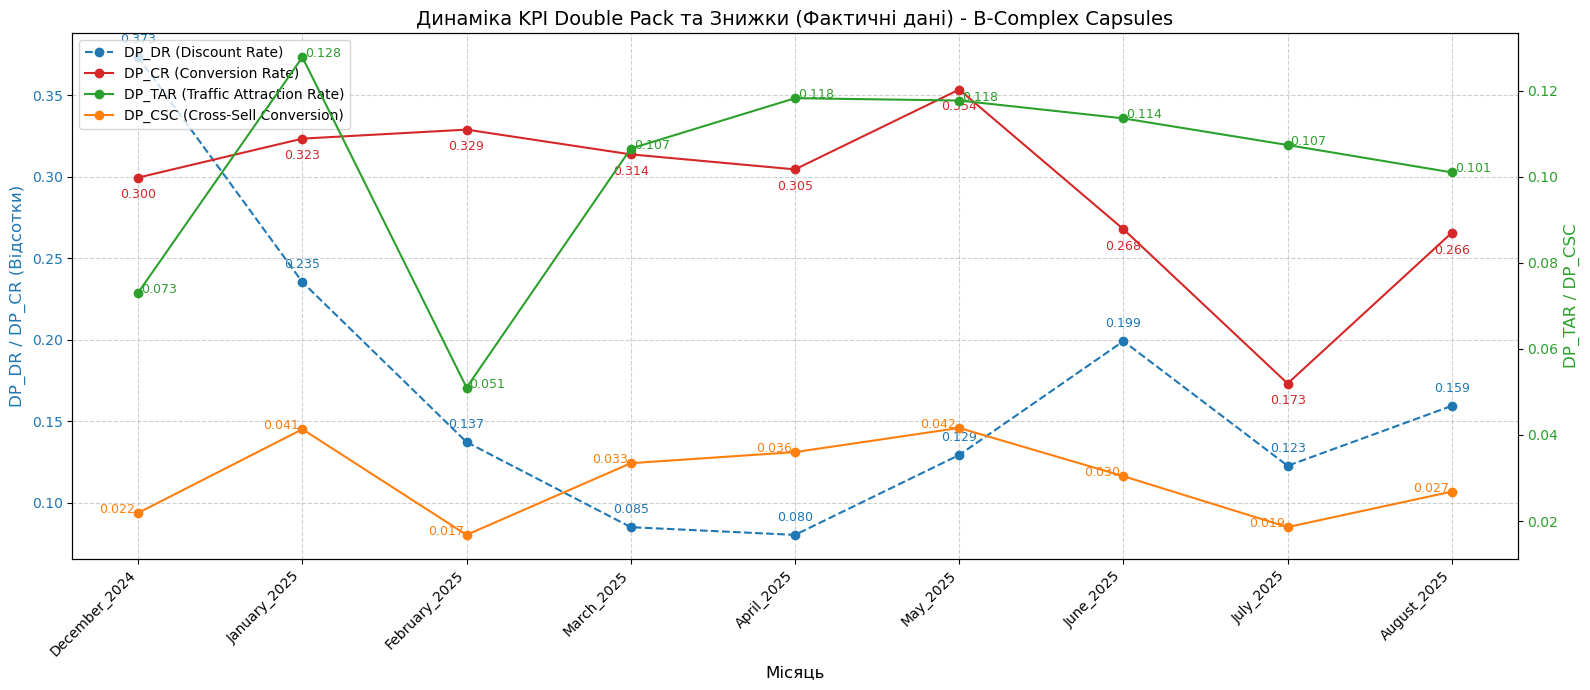


[ЗБЕРЕЖЕННЯ]: Дані KPI для 'B-Complex Capsules' збережено у ALL_PRODUCTS_KPI.


In [3]:
# --- Розрахунок KPI та Аналіз Кореляції ---

# Примітка: Вважається, що змінні df_comparison_pivot, product_name та функція create_sort_key

# 1. Підготовка даних
df_kpi = df_comparison_pivot.copy()

# 2. Створення DataFrame для розрахунків KPI (Місяці як індекс)
metrics_for_calc = ['Sessions', 'Units Ordered', 'Actual Price']
df_calc = df_kpi.loc[metrics_for_calc].T.copy()
df_calc.index.names = ['Month_Year', 'Pack_Type']

# Розділяємо дані по паках для легшого доступу
df_sp = df_calc[df_calc.index.get_level_values('Pack_Type') == 'Single Pack'].droplevel('Pack_Type')
df_dp = df_calc[df_calc.index.get_level_values('Pack_Type') == 'Double Pack'].droplevel('Pack_Type')

# Об'єднуємо обидва DF за місяцями
df_raw = df_sp.join(df_dp, lsuffix='_SP', rsuffix='_DP')


# 3. Розрахунок KPI (помісячно)

# 3.1. Розрахунок DP_DR (Discount Rate - Відсоток Знижки)
df_raw['DP_DR'] = 1 - (df_raw['Actual Price_DP'] / (df_raw['Actual Price_SP'] * 2))

# 3.2. Розрахунок DP_CR (Conversion Rate - Конверсія продажів Double Pack)
df_raw['DP_CR'] = df_raw['Units Ordered_DP'] / df_raw['Sessions_DP']

# 3.3. Розрахунок DP_TAR (Traffic Attraction Rate - Конверсія залученості Double Pack)
df_raw['DP_TAR'] = df_raw['Sessions_DP'] / df_raw['Sessions_SP']

# 3.4. Розрахунок DP_CSC (Cross-Sell Conversion - Крос-продажна конверсія)
df_raw['DP_CSC'] = df_raw['Units Ordered_DP'] / df_raw['Sessions_SP']

# 4. Створення фінального DataFrame з KPI
df_kpi_calculated = df_raw[['DP_DR', 'DP_CR', 'DP_TAR', 'DP_CSC']].copy()

# Транспонуємо для формату: Метрики (рядки) x Місяці (колонки)
df_kpi_pivot = df_kpi_calculated.T

# Забезпечуємо правильний порядок рядків
kpi_order = ['DP_DR', 'DP_CR', 'DP_TAR', 'DP_CSC']
df_kpi_pivot = df_kpi_pivot.reindex(kpi_order)


# --- 5. РОЗРАХУНОК ТА ВИВЕДЕННЯ КОЕФІЦІЄНТІВ КОРЕЛЯЦІЇ ---

# Розраховуємо кореляцію DP_DR з іншими показниками
corr_cr = df_kpi_calculated['DP_CR'].corr(df_kpi_calculated['DP_DR'])
corr_tar = df_kpi_calculated['DP_TAR'].corr(df_kpi_calculated['DP_DR'])
corr_csc = df_kpi_calculated['DP_CSC'].corr(df_kpi_calculated['DP_DR'])

print("\n--- СЕРВІСНА ІНФОРМАЦІЯ: Коефіцієнти Кореляції ---")
print(f"Коефіцієнт DP_CR та DP_DR кореляції: {corr_cr:.4f}")
print(f"Коефіцієнт DP_TAR та DP_DR кореляції: {corr_tar:.4f}")
print(f"Коефіцієнт DP_CSC та DP_DR кореляції: {corr_csc:.4f}")
print("-" * 50)


# --- 6. ВИВЕДЕННЯ ЗВЕДЕНОЇ ТАБЛИЦІ KPI ---

print("\n--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---")
df_kpi_styled = df_kpi_pivot.style.format('{:.4f}')
display(df_kpi_styled)


# --- 7. БУДУВАННЯ СПІЛЬНОГО ЛІНІЙНОГО ГРАФІКА (З ПОКРАЩЕННЯМИ) ---

# Використовуємо df_kpi_calculated (фактичні значення, Місяці - індекс)
df_plot = df_kpi_calculated.copy()

# Налаштування графіка
fig, ax1 = plt.subplots(figsize=(16, 7))

# Визначення кольорів
colors = {'DP_DR': 'tab:blue', 'DP_CR': 'tab:red', 'DP_TAR': 'tab:green', 'DP_CSC': 'tab:orange'}
line_styles = {'DP_DR': '--', 'DP_CR': '-', 'DP_TAR': '-', 'DP_CSC': '-'}
markers = 'o'
font_size_labels = 9

# --- ЛІВА ВІСЬ (AX1): DP_DR та DP_CR (Відсотки) ---
ax1.set_xlabel('Місяць', fontsize=12)
ax1.set_ylabel('DP_DR / DP_CR (Відсотки)', color=colors['DP_DR'], fontsize=12)
ax1.tick_params(axis='y', labelcolor=colors['DP_DR'])
ax1.grid(True, linestyle='--', alpha=0.6)

# Побудова DP_DR (пунктирна лінія)
p1 = ax1.plot(df_plot.index, df_plot['DP_DR'], label='DP_DR (Discount Rate)', color=colors['DP_DR'], 
              linestyle=line_styles['DP_DR'], marker=markers)

# Побудова DP_CR (суцільна лінія)
p2 = ax1.plot(df_plot.index, df_plot['DP_CR'], label='DP_CR (Conversion Rate)', color=colors['DP_CR'], 
              linestyle=line_styles['DP_CR'], marker=markers)

# Додавання підписів DP_DR та DP_CR
for i, month in enumerate(df_plot.index):
    # DP_DR
    ax1.annotate(f"{df_plot['DP_DR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_DR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_DR'])
    # DP_CR
    ax1.annotate(f"{df_plot['DP_CR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_CR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(0,-15), 
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_CR'])


# --- ПРАВА ВІСЬ (AX2): DP_TAR та DP_CSC ---
ax2 = ax1.twinx()
ax2.set_ylabel('DP_TAR / DP_CSC', color=colors['DP_TAR'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=colors['DP_TAR'])

# Побудова DP_TAR
p3 = ax2.plot(df_plot.index, df_plot['DP_TAR'], label='DP_TAR (Traffic Attraction Rate)', color=colors['DP_TAR'], 
              linestyle=line_styles['DP_TAR'], marker=markers)

# Побудова DP_CSC
p4 = ax2.plot(df_plot.index, df_plot['DP_CSC'], label='DP_CSC (Cross-Sell Conversion)', color=colors['DP_CSC'], 
              linestyle=line_styles['DP_CSC'], marker=markers)

# Додавання підписів DP_TAR та DP_CSC
for i, month in enumerate(df_plot.index):
    # DP_TAR
    ax2.annotate(f"{df_plot['DP_TAR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_TAR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(15, 0), # Зміщено праворуч
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_TAR'])
    # DP_CSC
    ax2.annotate(f"{df_plot['DP_CSC'].iloc[i]:.3f}", 
                 (month, df_plot['DP_CSC'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(-15, 0), # Зміщено ліворуч
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_CSC'])


# --- Фінальні налаштування ---
plt.title(f'Динаміка KPI Double Pack та Знижки (Фактичні дані) - {product_name}', fontsize=14)
ax1.set_xticks(df_plot.index)
ax1.set_xticklabels(df_plot.index, rotation=45, ha='right')

# Об'єднання легенд
lines = p1 + p2 + p3 + p4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.8)

fig.tight_layout()
plt.show()

# Запис даних для виведення в загальні графіки
ALL_PRODUCTS_KPI[product_name] = df_kpi_calculated
print(f"\n[ЗБЕРЕЖЕННЯ]: Дані KPI для '{product_name}' збережено у ALL_PRODUCTS_KPI.")

### ПРОДУКТ: Cinnamon Capsules
### КРОК 2.1: Агрегація та консолідація історичних даних

In [4]:
# ⚠️ ЗМІННІ ДЛЯ РУЧНОЇ ЗМІНИ
# ----------------------------------------------------------------------------------------------------------------------
product_name = 'Cinnamon Capsules' 
product_dir = '/Users/radyslav/data_analysis/Amazon/prod_perc_dpack/Cinnamon Capsules' # Повний шлях до директорії
# ----------------------------------------------------------------------------------------------------------------------

# Визначаємо кореневу директорію та назву файлу констант
root_dir = os.path.dirname(product_dir)
costs_file_name = 'Product Cost Info.xlsx'
costs_file_path = os.path.join(root_dir, costs_file_name)

# Визначаємо базову назву продукту для фільтрації констант
base_product_name = product_name.replace(' Capsules', '').replace('(Stable Price)', '').strip()


# --- 2. ФУНКЦІЇ ДЛЯ ОБРОБКИ ДАНИХ ---

def get_product_unit_economics(file_path, base_name):
    """Витягує фінансові константи (COGS, FBA Fee, Ref Fee Rate, ASIN)."""
    try:
        df_costs = pd.read_excel(file_path, header=0)
    except FileNotFoundError:
        print(f"Помилка: Файл собівартості не знайдено за шляхом: {file_path}")
        return {}
    
    # Очищення та фільтрація
    df_costs.columns = df_costs.columns.str.strip().str.lower().str.replace(' ', '_')
    df_costs = df_costs.dropna(subset=['short_product_name']).reset_index(drop=True)

    df_product_group = df_costs[df_costs['short_product_name'].str.contains(base_name, case=False, na=False)].copy()

    if df_product_group.empty: return {}

    # Ідентифікація паків за кількістю одиниць
    df_product_group['unit_count'] = df_product_group['short_product_name'].str.extract(r'(\d+)').astype(float)
    df_product_group = df_product_group.dropna(subset=['unit_count'])
    if len(df_product_group) < 2: return {}

    idx_dp = df_product_group['unit_count'].idxmax()
    idx_sp = df_product_group['unit_count'].idxmin()

    results_raw = {'Single Pack': df_product_group.loc[idx_sp], 'Double Pack': df_product_group.loc[idx_dp]}
    unit_economics_final = {}
    
    # Очищення та перетворення констант
    for pack_type, data in results_raw.items():
        costs = {}
        for col in ['cogs', 'fba_fee']:
            raw_value = str(data.get(col, 0))
            cleaned_value = raw_value.strip().replace('$', '').replace(',', '')
            costs[col] = pd.to_numeric(cleaned_value, errors='coerce') 

        raw_ref_fee = str(data.get('ref_fee', '0%'))
        if '%' in raw_ref_fee:
              ref_fee_rate = pd.to_numeric(raw_ref_fee.strip().replace('%', ''), errors='coerce') / 100
        else:
              numeric_val = pd.to_numeric(raw_ref_fee, errors='coerce')
              ref_fee_rate = numeric_val / 100 if numeric_val > 1 else numeric_val

        costs['ref_fee_rate'] = ref_fee_rate
        costs['asin'] = data['asin'] 
        unit_economics_final[pack_type] = costs

    return unit_economics_final

def process_single_csv(file_path, file_name, current_asin):
    """Обробляє один CSV-файл, об'єднує Total/B2B метрики та витягує дату."""
    try:
        df = pd.read_csv(file_path, header=0, encoding='utf-8')
    except Exception as e:
        print(f"Помилка зчитування файлу {file_name}: {e}")
        return None, 0

    cols_mapping = {
        'Sessions': ['Sessions - Total', 'Sessions - Total - B2B'],
        'Units Ordered': ['Units Ordered', 'Units Ordered - B2B'],
        'Ordered Product Sales': ['Ordered Product Sales', 'Ordered Product Sales - B2B']
    }
    
    monthly_data = {'ASIN': current_asin}
    
    for new_col, raw_cols in cols_mapping.items():
        temp_df = df[raw_cols].copy()
        for col in raw_cols:
            if temp_df[col].dtype == object: 
                temp_df[col] = temp_df[col].astype(str).str.replace(r'[\$,\s]', '', regex=True)
            temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
        
        total_sum = temp_df.sum().sum() 
        monthly_data[new_col] = total_sum

    date_match = re.search(r'([A-Za-z]+_\d{4})', file_name)
    monthly_data['Month_Year'] = date_match.group(1) if date_match else "Unknown_Date"

    return pd.DataFrame([monthly_data]), len(df)

def create_sort_key(month_year_str):
    """Створює ключ сортування datetime для Month_Year."""
    if '_' in month_year_str:
        date_str = month_year_str.replace('_', ' ')
        try:
            return pd.to_datetime(date_str, format='%B %Y') 
        except ValueError:
            return pd.NaT 
    return pd.NaT


# --- 3. ДИНАМІЧНИЙ ПОШУК ПАКІВ ТА ПІДГОТОВКА ---

if not os.path.isdir(product_dir):
    raise FileNotFoundError(f"Помилка: Директорія продукту '{product_dir}' не знайдена.")

all_items = os.listdir(product_dir)
single_pack_folder = next((item for item in all_items if "single pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)
double_pack_folder = next((item for item in all_items if "double pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)

if not single_pack_folder or not double_pack_folder:
      raise FileNotFoundError("Помилка: Не знайдено підпапок 'Single Pack' або 'Double Pack'.")

single_pack_dir = os.path.join(product_dir, single_pack_folder)
double_pack_dir = os.path.join(product_dir, double_pack_folder)

pack_dirs = {'Single Pack': single_pack_dir, 'Double Pack': double_pack_dir}

def count_csv_files(directory):
    if not os.path.isdir(directory): return 0, []
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    return len(csv_files), csv_files 
_, single_files_list = count_csv_files(single_pack_dir)
_, double_files_list = count_csv_files(double_pack_dir)
pack_files = {'Single Pack': single_files_list, 'Double Pack': double_files_list}

unit_economics = get_product_unit_economics(costs_file_path, base_product_name)

# Змінні для Сервісної Інформації
total_rows_sp = 0
total_rows_dp = 0


# --- 4. АГРЕГАЦІЯ, KPI ТА ФІНАЛІЗАЦІЯ: SINGLE PACK ---
pack_type = 'Single Pack'
asin_sp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

single_pack_data = []
for file_name in pack_files[pack_type]:
    df_month, rows_count = process_single_csv(os.path.join(pack_dirs[pack_type], file_name), file_name, asin_sp)
    if df_month is not None: 
        single_pack_data.append(df_month)
        total_rows_sp += rows_count # Додавання оброблених рядків

df_single_raw = pd.concat(single_pack_data, ignore_index=True)
df_single_raw['Date_Sort'] = df_single_raw['Month_Year'].apply(create_sort_key)
df_single_kpi = df_single_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# Розрахунок Фінансових Метрик (Net Profit)
if unit_economics and pack_type in unit_economics:
    cogs = unit_economics[pack_type]['cogs']
    fba_fee = unit_economics[pack_type]['fba_fee']
    ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']
    
    df_single_kpi['Product Costs'] = (df_single_kpi['Units Ordered'] * (cogs + fba_fee)) + \
                                     (df_single_kpi['Ordered Product Sales'] * ref_fee_rate)
    
    df_single_kpi['Net Profit'] = df_single_kpi['Ordered Product Sales'] - df_single_kpi['Product Costs']
else:
    cogs = np.nan 
    fba_fee = np.nan 
    ref_fee_rate = np.nan 
    df_single_kpi['Product Costs'] = np.nan
    df_single_kpi['Net Profit'] = np.nan

# Розрахунок Actual Price
df_single_kpi['Actual Price'] = df_single_kpi['Ordered Product Sales'] / df_single_kpi['Units Ordered']
    
# Змінні для Сервісної Інформації (Single Pack)
sp_consts_info = f"COGS: {cogs:.2f}, FBA Fee: {fba_fee:.2f}, Ref Rate: {ref_fee_rate:.2%}"

# Створення Фінального Датасету для Single Pack
final_cols_sp = ['Month_Year', 'Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price', 'Date_Sort']
df_single_final = df_single_kpi[final_cols_sp].copy()
months_single_all = set(df_single_final['Month_Year'].unique()) # Всі місяці SP


# --- 5. АГРЕГАЦІЯ, KPI ТА ФІНАЛІЗАЦІЯ: DOUBLE PACK ---
pack_type = 'Double Pack'
asin_dp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

double_pack_data = []
for file_name in pack_files[pack_type]:
    df_month, rows_count = process_single_csv(os.path.join(pack_dirs[pack_type], file_name), file_name, asin_dp)
    if df_month is not None: 
        double_pack_data.append(df_month)
        total_rows_dp += rows_count # Додавання оброблених рядків

df_double_raw = pd.concat(double_pack_data, ignore_index=True)
df_double_raw['Date_Sort'] = df_double_raw['Month_Year'].apply(create_sort_key)
df_double_kpi = df_double_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# Розрахунок Фінансових Метрик (Net Profit)
if unit_economics and pack_type in unit_economics:
    cogs = unit_economics[pack_type]['cogs']
    fba_fee = unit_economics[pack_type]['fba_fee']
    ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']
    
    df_double_kpi['Product Costs'] = (df_double_kpi['Units Ordered'] * (cogs + fba_fee)) + \
                                     (df_double_kpi['Ordered Product Sales'] * ref_fee_rate)
    
    df_double_kpi['Net Profit'] = df_double_kpi['Ordered Product Sales'] - df_double_kpi['Product Costs']
else:
    cogs = np.nan 
    fba_fee = np.nan 
    ref_fee_rate = np.nan 
    df_double_kpi['Product Costs'] = np.nan
    df_double_kpi['Net Profit'] = np.nan

# Розрахунок Actual Price
df_double_kpi['Actual Price'] = df_double_kpi['Ordered Product Sales'] / df_double_kpi['Units Ordered']

# Змінні для Сервісної Інформації (Double Pack)
dp_consts_info = f"COGS: {cogs:.2f}, FBA Fee: {fba_fee:.2f}, Ref Rate: {ref_fee_rate:.2%}"

# Створення Фінального Датасету для Double Pack
df_double_final = df_double_kpi[final_cols_sp].copy()
months_double_all = set(df_double_final['Month_Year'].unique()) # Всі місяці DP


# --- 6. СЕРВІСНА ІНФОРМАЦІЯ ТА ФІНАЛЬНИЙ ВИВІД ---

# 6.1: КОНСОЛІДАЦІЯ ТА ПІДГОТОВКА ДО ВИВОДУ
months_single = set(df_single_final['Month_Year'].unique())
months_double = set(df_double_final['Month_Year'].unique())
common_months = sorted(list(months_single.intersection(months_double)), key=create_sort_key)
pack_type_order = ['Single Pack', 'Double Pack']

# Визначення не спільних місяців
non_common_months = (months_single_all.difference(common_months)).union(months_double_all.difference(common_months))
non_common_months_list = sorted(list(non_common_months), key=create_sort_key)
non_common_months_output = ', '.join(non_common_months_list) if non_common_months_list else "Всі місяці співпали"


# 6.2: ДРУК СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"\n--- СЕРВІСНА ІНФОРМАЦІЯ ДЛЯ ЗВІРКИ ---")
print(f"Аналізований Продукт: {product_name}")
print(f"Назва продукту: {base_product_name}")
print(f"Коренева директорія продукту: {root_dir}")
print("-" * 50)

print(f"Шлях Single Pack: {single_pack_dir}")
print(f"ASIN Single Pack: {asin_sp}")
print(f"Кількість файлів Single Pack: {len(pack_files['Single Pack'])}")
print(f"Кількість рядків, оброблених по всім CSV, Single Pack: {total_rows_sp}")
print(f"Показники констант юніт економіки Single Pack: {sp_consts_info}")
print("-" * 50)

print(f"Шлях Double Pack: {double_pack_dir}")
print(f"ASIN Double Pack: {asin_dp}")
print(f"Кількість файлів Double Pack: {len(pack_files['Double Pack'])}")
print(f"Кількість рядків, оброблених по всім CSV, Double Pack: {total_rows_dp}")
print(f"Показники констант юніт економіки Double Pack: {dp_consts_info}")
print("-" * 50)

print(f"Місяці, що не є спільними для Single Pack та Double Pack: {non_common_months_output}")
print("-" * 50)


# 6.3: СТВОРЕННЯ ЄДИНОГО ПОРІВНЯЛЬНОГО ДАТАСЕТУ
if not common_months:
    print("❌ Помилка: Спільних місяців для порівняння не знайдено. Фінальна таблиця порожня.")
    df_comparison_pivot = pd.DataFrame() 
else:
    # Об'єднання та Фільтрація
    df_single_combined = df_single_final.assign(Pack_Type='Single Pack')
    df_double_combined = df_double_final.assign(Pack_Type='Double Pack')
    df_combined = pd.concat([df_single_combined, df_double_combined], ignore_index=True)
    df_combined_filtered = df_combined[df_combined['Month_Year'].isin(common_months)].copy()

    # Трансформація: Melt та Pivot
    df_combined_filtered['Pack_Type'] = pd.Categorical(df_combined_filtered['Pack_Type'], categories=pack_type_order, ordered=True)
    comparison_values = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price']

    df_for_pivot = df_combined_filtered[['Month_Year', 'Pack_Type'] + comparison_values].melt(
        id_vars=['Month_Year', 'Pack_Type'],
        value_vars=comparison_values,
        var_name='Metric',
        value_name='Value'
    )
    
    # Сортування перед Pivot
    df_for_pivot['Date_Sort'] = df_for_pivot['Month_Year'].apply(create_sort_key)
    df_for_pivot = df_for_pivot.sort_values(by=['Date_Sort', 'Pack_Type']).drop(columns=['Date_Sort'])
    
    # Фінальний Pivot
    df_comparison_pivot = df_for_pivot.pivot_table(
        index='Metric', 
        columns=['Month_Year', 'Pack_Type'], 
        values='Value',
        aggfunc='sum',
        observed=False 
    )

    # Сортування Колонок та Рядків
    sorted_cols = []
    for month in common_months:
        for pack in pack_type_order:
            sorted_cols.append((month, pack))

    df_comparison_pivot = df_comparison_pivot[sorted_cols]
    df_comparison_pivot.columns.names = ['Month_Year', 'Pack_Type']
    
    # Сортування рядків з додаванням 'Actual Price'
    row_order_final = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price']
    df_comparison_pivot = df_comparison_pivot.reindex(row_order_final)
    
    
    # 6.4: Виведення Результату
    print("\n--- ЗВЕДЕНА ТАБЛИЦЯ: Історичні Показники SP vs DP ---")
    
    # Форматування виводу: {:.2f} (float64 без роздільників розрядів)
    df_comparison_pivot_styled = df_comparison_pivot.style.format('{:.2f}')
    display(df_comparison_pivot_styled)


--- СЕРВІСНА ІНФОРМАЦІЯ ДЛЯ ЗВІРКИ ---
Аналізований Продукт: Cinnamon Capsules
Назва продукту: Cinnamon
Коренева директорія продукту: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack
--------------------------------------------------
Шлях Single Pack: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack/Cinnamon Capsules/Cinnamon 60 Capsules (Single Pack)
ASIN Single Pack: B0CYT7XGVP
Кількість файлів Single Pack: 11
Кількість рядків, оброблених по всім CSV, Single Pack: 17
Показники констант юніт економіки Single Pack: COGS: 2.68, FBA Fee: 3.68, Ref Rate: 15.00%
--------------------------------------------------
Шлях Double Pack: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack/Cinnamon Capsules/Cinnamon 120 Capsules (Double Pack)
ASIN Double Pack: B0DGQSMXYF
Кількість файлів Double Pack: 10
Кількість рядків, оброблених по всім CSV, Double Pack: 15
Показники констант юніт економіки Double Pack: COGS: 4.26, FBA Fee: 3.90, Ref Rate: 15.00%
---------------------------------------

### ПРОДУКТ: Cinnamon Capsules
### КРОК 2.2: Розрахунок KPI, аналіз кореляції, побудова зведеного графіку


--- СЕРВІСНА ІНФОРМАЦІЯ: Коефіцієнти Кореляції ---
Коефіцієнт DP_CR та DP_DR кореляції: 0.0408
Коефіцієнт DP_TAR та DP_DR кореляції: 0.4000
Коефіцієнт DP_CSC та DP_DR кореляції: 0.3530
--------------------------------------------------

--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---


Month_Year,November_2024,December_2024,January_2025,February_2025,March_2025,April_2025,May_2025,June_2025,July_2025,August_2025
Metric,,,,,,,,,,
DP_DR,-0.0333,0.1225,0.0478,-0.0016,0.0369,0.0262,0.0274,0.0753,0.0464,0.0828
DP_CR,0.3189,0.4172,0.3951,0.3749,0.3637,0.4483,0.4835,0.4906,0.4435,0.1888
DP_TAR,0.0275,0.1179,0.0822,0.0634,0.2314,0.1124,0.0970,0.1188,0.1185,0.1025
DP_CSC,0.0088,0.0492,0.0325,0.0238,0.0841,0.0504,0.0469,0.0583,0.0525,0.0193


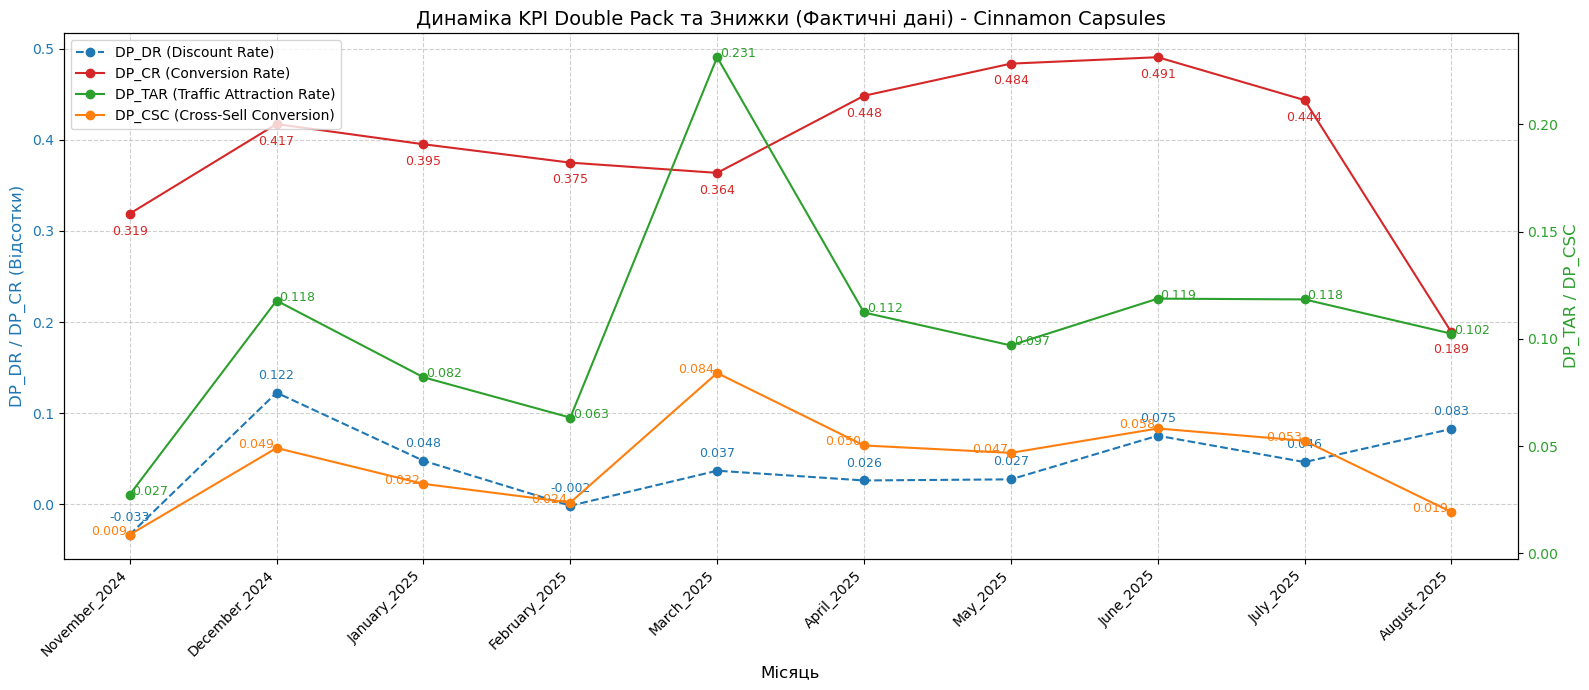


[ЗБЕРЕЖЕННЯ]: Дані KPI для 'Cinnamon Capsules' збережено у ALL_PRODUCTS_KPI.


In [5]:
# --- Розрахунок KPI та Аналіз Кореляції ---

# Примітка: Вважається, що змінні df_comparison_pivot, product_name та функція create_sort_key

# 1. Підготовка даних
df_kpi = df_comparison_pivot.copy()

# 2. Створення DataFrame для розрахунків KPI (Місяці як індекс)
metrics_for_calc = ['Sessions', 'Units Ordered', 'Actual Price']
df_calc = df_kpi.loc[metrics_for_calc].T.copy()
df_calc.index.names = ['Month_Year', 'Pack_Type']

# Розділяємо дані по паках для легшого доступу
df_sp = df_calc[df_calc.index.get_level_values('Pack_Type') == 'Single Pack'].droplevel('Pack_Type')
df_dp = df_calc[df_calc.index.get_level_values('Pack_Type') == 'Double Pack'].droplevel('Pack_Type')

# Об'єднуємо обидва DF за місяцями
df_raw = df_sp.join(df_dp, lsuffix='_SP', rsuffix='_DP')


# 3. Розрахунок KPI (помісячно)

# 3.1. Розрахунок DP_DR (Discount Rate - Відсоток Знижки)
df_raw['DP_DR'] = 1 - (df_raw['Actual Price_DP'] / (df_raw['Actual Price_SP'] * 2))

# 3.2. Розрахунок DP_CR (Conversion Rate - Конверсія продажів Double Pack)
df_raw['DP_CR'] = df_raw['Units Ordered_DP'] / df_raw['Sessions_DP']

# 3.3. Розрахунок DP_TAR (Traffic Attraction Rate - Конверсія залученості Double Pack)
df_raw['DP_TAR'] = df_raw['Sessions_DP'] / df_raw['Sessions_SP']

# 3.4. Розрахунок DP_CSC (Cross-Sell Conversion - Крос-продажна конверсія)
df_raw['DP_CSC'] = df_raw['Units Ordered_DP'] / df_raw['Sessions_SP']

# 4. Створення фінального DataFrame з KPI
df_kpi_calculated = df_raw[['DP_DR', 'DP_CR', 'DP_TAR', 'DP_CSC']].copy()

# Транспонуємо для формату: Метрики (рядки) x Місяці (колонки)
df_kpi_pivot = df_kpi_calculated.T

# Забезпечуємо правильний порядок рядків
kpi_order = ['DP_DR', 'DP_CR', 'DP_TAR', 'DP_CSC']
df_kpi_pivot = df_kpi_pivot.reindex(kpi_order)


# --- 5. РОЗРАХУНОК ТА ВИВЕДЕННЯ КОЕФІЦІЄНТІВ КОРЕЛЯЦІЇ ---

# Розраховуємо кореляцію DP_DR з іншими показниками
corr_cr = df_kpi_calculated['DP_CR'].corr(df_kpi_calculated['DP_DR'])
corr_tar = df_kpi_calculated['DP_TAR'].corr(df_kpi_calculated['DP_DR'])
corr_csc = df_kpi_calculated['DP_CSC'].corr(df_kpi_calculated['DP_DR'])

print("\n--- СЕРВІСНА ІНФОРМАЦІЯ: Коефіцієнти Кореляції ---")
print(f"Коефіцієнт DP_CR та DP_DR кореляції: {corr_cr:.4f}")
print(f"Коефіцієнт DP_TAR та DP_DR кореляції: {corr_tar:.4f}")
print(f"Коефіцієнт DP_CSC та DP_DR кореляції: {corr_csc:.4f}")
print("-" * 50)


# --- 6. ВИВЕДЕННЯ ЗВЕДЕНОЇ ТАБЛИЦІ KPI ---

print("\n--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---")
df_kpi_styled = df_kpi_pivot.style.format('{:.4f}')
display(df_kpi_styled)


# --- 7. БУДУВАННЯ СПІЛЬНОГО ЛІНІЙНОГО ГРАФІКА (З ПОКРАЩЕННЯМИ) ---

# Використовуємо df_kpi_calculated (фактичні значення, Місяці - індекс)
df_plot = df_kpi_calculated.copy()

# Налаштування графіка
fig, ax1 = plt.subplots(figsize=(16, 7))

# Визначення кольорів
colors = {'DP_DR': 'tab:blue', 'DP_CR': 'tab:red', 'DP_TAR': 'tab:green', 'DP_CSC': 'tab:orange'}
line_styles = {'DP_DR': '--', 'DP_CR': '-', 'DP_TAR': '-', 'DP_CSC': '-'}
markers = 'o'
font_size_labels = 9

# --- ЛІВА ВІСЬ (AX1): DP_DR та DP_CR (Відсотки) ---
ax1.set_xlabel('Місяць', fontsize=12)
ax1.set_ylabel('DP_DR / DP_CR (Відсотки)', color=colors['DP_DR'], fontsize=12)
ax1.tick_params(axis='y', labelcolor=colors['DP_DR'])
ax1.grid(True, linestyle='--', alpha=0.6)

# Побудова DP_DR (пунктирна лінія)
p1 = ax1.plot(df_plot.index, df_plot['DP_DR'], label='DP_DR (Discount Rate)', color=colors['DP_DR'], 
              linestyle=line_styles['DP_DR'], marker=markers)

# Побудова DP_CR (суцільна лінія)
p2 = ax1.plot(df_plot.index, df_plot['DP_CR'], label='DP_CR (Conversion Rate)', color=colors['DP_CR'], 
              linestyle=line_styles['DP_CR'], marker=markers)

# Додавання підписів DP_DR та DP_CR
for i, month in enumerate(df_plot.index):
    # DP_DR
    ax1.annotate(f"{df_plot['DP_DR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_DR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_DR'])
    # DP_CR
    ax1.annotate(f"{df_plot['DP_CR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_CR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(0,-15), 
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_CR'])


# --- ПРАВА ВІСЬ (AX2): DP_TAR та DP_CSC ---
ax2 = ax1.twinx()
ax2.set_ylabel('DP_TAR / DP_CSC', color=colors['DP_TAR'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=colors['DP_TAR'])

# Побудова DP_TAR
p3 = ax2.plot(df_plot.index, df_plot['DP_TAR'], label='DP_TAR (Traffic Attraction Rate)', color=colors['DP_TAR'], 
              linestyle=line_styles['DP_TAR'], marker=markers)

# Побудова DP_CSC
p4 = ax2.plot(df_plot.index, df_plot['DP_CSC'], label='DP_CSC (Cross-Sell Conversion)', color=colors['DP_CSC'], 
              linestyle=line_styles['DP_CSC'], marker=markers)

# Додавання підписів DP_TAR та DP_CSC
for i, month in enumerate(df_plot.index):
    # DP_TAR
    ax2.annotate(f"{df_plot['DP_TAR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_TAR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(15, 0), # Зміщено праворуч
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_TAR'])
    # DP_CSC
    ax2.annotate(f"{df_plot['DP_CSC'].iloc[i]:.3f}", 
                 (month, df_plot['DP_CSC'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(-15, 0), # Зміщено ліворуч
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_CSC'])


# --- Фінальні налаштування ---
plt.title(f'Динаміка KPI Double Pack та Знижки (Фактичні дані) - {product_name}', fontsize=14)
ax1.set_xticks(df_plot.index)
ax1.set_xticklabels(df_plot.index, rotation=45, ha='right')

# Об'єднання легенд
lines = p1 + p2 + p3 + p4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.8)

fig.tight_layout()
plt.show()

# Запис даних для виведення в загальні графіки
ALL_PRODUCTS_KPI[product_name] = df_kpi_calculated
print(f"\n[ЗБЕРЕЖЕННЯ]: Дані KPI для '{product_name}' збережено у ALL_PRODUCTS_KPI.")

### ПРОДУКТ: D-Mannose Capsules
### КРОК 3.1: Агрегація та консолідація історичних даних

In [6]:
# ⚠️ ЗМІННІ ДЛЯ РУЧНОЇ ЗМІНИ
# ----------------------------------------------------------------------------------------------------------------------
product_name = 'D-Mannose Capsules' 
product_dir = '/Users/radyslav/data_analysis/Amazon/prod_perc_dpack/D-Mannose Capsules' # Повний шлях до директорії
# ----------------------------------------------------------------------------------------------------------------------

# Визначаємо кореневу директорію та назву файлу констант
root_dir = os.path.dirname(product_dir)
costs_file_name = 'Product Cost Info.xlsx'
costs_file_path = os.path.join(root_dir, costs_file_name)

# Визначаємо базову назву продукту для фільтрації констант
base_product_name = product_name.replace(' Capsules', '').replace('(Stable Price)', '').strip()


# --- 2. ФУНКЦІЇ ДЛЯ ОБРОБКИ ДАНИХ ---

def get_product_unit_economics(file_path, base_name):
    """Витягує фінансові константи (COGS, FBA Fee, Ref Fee Rate, ASIN)."""
    try:
        df_costs = pd.read_excel(file_path, header=0)
    except FileNotFoundError:
        print(f"Помилка: Файл собівартості не знайдено за шляхом: {file_path}")
        return {}
    
    # Очищення та фільтрація
    df_costs.columns = df_costs.columns.str.strip().str.lower().str.replace(' ', '_')
    df_costs = df_costs.dropna(subset=['short_product_name']).reset_index(drop=True)

    df_product_group = df_costs[df_costs['short_product_name'].str.contains(base_name, case=False, na=False)].copy()

    if df_product_group.empty: return {}

    # Ідентифікація паків за кількістю одиниць
    df_product_group['unit_count'] = df_product_group['short_product_name'].str.extract(r'(\d+)').astype(float)
    df_product_group = df_product_group.dropna(subset=['unit_count'])
    if len(df_product_group) < 2: return {}

    idx_dp = df_product_group['unit_count'].idxmax()
    idx_sp = df_product_group['unit_count'].idxmin()

    results_raw = {'Single Pack': df_product_group.loc[idx_sp], 'Double Pack': df_product_group.loc[idx_dp]}
    unit_economics_final = {}
    
    # Очищення та перетворення констант
    for pack_type, data in results_raw.items():
        costs = {}
        for col in ['cogs', 'fba_fee']:
            raw_value = str(data.get(col, 0))
            cleaned_value = raw_value.strip().replace('$', '').replace(',', '')
            costs[col] = pd.to_numeric(cleaned_value, errors='coerce') 

        raw_ref_fee = str(data.get('ref_fee', '0%'))
        if '%' in raw_ref_fee:
              ref_fee_rate = pd.to_numeric(raw_ref_fee.strip().replace('%', ''), errors='coerce') / 100
        else:
              numeric_val = pd.to_numeric(raw_ref_fee, errors='coerce')
              ref_fee_rate = numeric_val / 100 if numeric_val > 1 else numeric_val

        costs['ref_fee_rate'] = ref_fee_rate
        costs['asin'] = data['asin'] 
        unit_economics_final[pack_type] = costs

    return unit_economics_final

def process_single_csv(file_path, file_name, current_asin):
    """Обробляє один CSV-файл, об'єднує Total/B2B метрики та витягує дату."""
    try:
        df = pd.read_csv(file_path, header=0, encoding='utf-8')
    except Exception as e:
        print(f"Помилка зчитування файлу {file_name}: {e}")
        return None, 0

    cols_mapping = {
        'Sessions': ['Sessions - Total', 'Sessions - Total - B2B'],
        'Units Ordered': ['Units Ordered', 'Units Ordered - B2B'],
        'Ordered Product Sales': ['Ordered Product Sales', 'Ordered Product Sales - B2B']
    }
    
    monthly_data = {'ASIN': current_asin}
    
    for new_col, raw_cols in cols_mapping.items():
        temp_df = df[raw_cols].copy()
        for col in raw_cols:
            if temp_df[col].dtype == object: 
                temp_df[col] = temp_df[col].astype(str).str.replace(r'[\$,\s]', '', regex=True)
            temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
        
        total_sum = temp_df.sum().sum() 
        monthly_data[new_col] = total_sum

    date_match = re.search(r'([A-Za-z]+_\d{4})', file_name)
    monthly_data['Month_Year'] = date_match.group(1) if date_match else "Unknown_Date"

    return pd.DataFrame([monthly_data]), len(df)

def create_sort_key(month_year_str):
    """Створює ключ сортування datetime для Month_Year."""
    if '_' in month_year_str:
        date_str = month_year_str.replace('_', ' ')
        try:
            return pd.to_datetime(date_str, format='%B %Y') 
        except ValueError:
            return pd.NaT 
    return pd.NaT


# --- 3. ДИНАМІЧНИЙ ПОШУК ПАКІВ ТА ПІДГОТОВКА ---

if not os.path.isdir(product_dir):
    raise FileNotFoundError(f"Помилка: Директорія продукту '{product_dir}' не знайдена.")

all_items = os.listdir(product_dir)
single_pack_folder = next((item for item in all_items if "single pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)
double_pack_folder = next((item for item in all_items if "double pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)

if not single_pack_folder or not double_pack_folder:
      raise FileNotFoundError("Помилка: Не знайдено підпапок 'Single Pack' або 'Double Pack'.")

single_pack_dir = os.path.join(product_dir, single_pack_folder)
double_pack_dir = os.path.join(product_dir, double_pack_folder)

pack_dirs = {'Single Pack': single_pack_dir, 'Double Pack': double_pack_dir}

def count_csv_files(directory):
    if not os.path.isdir(directory): return 0, []
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    return len(csv_files), csv_files 
_, single_files_list = count_csv_files(single_pack_dir)
_, double_files_list = count_csv_files(double_pack_dir)
pack_files = {'Single Pack': single_files_list, 'Double Pack': double_files_list}

unit_economics = get_product_unit_economics(costs_file_path, base_product_name)

# Змінні для Сервісної Інформації
total_rows_sp = 0
total_rows_dp = 0


# --- 4. АГРЕГАЦІЯ, KPI ТА ФІНАЛІЗАЦІЯ: SINGLE PACK ---
pack_type = 'Single Pack'
asin_sp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

single_pack_data = []
for file_name in pack_files[pack_type]:
    df_month, rows_count = process_single_csv(os.path.join(pack_dirs[pack_type], file_name), file_name, asin_sp)
    if df_month is not None: 
        single_pack_data.append(df_month)
        total_rows_sp += rows_count # Додавання оброблених рядків

df_single_raw = pd.concat(single_pack_data, ignore_index=True)
df_single_raw['Date_Sort'] = df_single_raw['Month_Year'].apply(create_sort_key)
df_single_kpi = df_single_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# Розрахунок Фінансових Метрик (Net Profit)
if unit_economics and pack_type in unit_economics:
    cogs = unit_economics[pack_type]['cogs']
    fba_fee = unit_economics[pack_type]['fba_fee']
    ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']
    
    df_single_kpi['Product Costs'] = (df_single_kpi['Units Ordered'] * (cogs + fba_fee)) + \
                                     (df_single_kpi['Ordered Product Sales'] * ref_fee_rate)
    
    df_single_kpi['Net Profit'] = df_single_kpi['Ordered Product Sales'] - df_single_kpi['Product Costs']
else:
    cogs = np.nan 
    fba_fee = np.nan 
    ref_fee_rate = np.nan 
    df_single_kpi['Product Costs'] = np.nan
    df_single_kpi['Net Profit'] = np.nan

# Розрахунок Actual Price
df_single_kpi['Actual Price'] = df_single_kpi['Ordered Product Sales'] / df_single_kpi['Units Ordered']
    
# Змінні для Сервісної Інформації (Single Pack)
sp_consts_info = f"COGS: {cogs:.2f}, FBA Fee: {fba_fee:.2f}, Ref Rate: {ref_fee_rate:.2%}"

# Створення Фінального Датасету для Single Pack
final_cols_sp = ['Month_Year', 'Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price', 'Date_Sort']
df_single_final = df_single_kpi[final_cols_sp].copy()
months_single_all = set(df_single_final['Month_Year'].unique()) # Всі місяці SP


# --- 5. АГРЕГАЦІЯ, KPI ТА ФІНАЛІЗАЦІЯ: DOUBLE PACK ---
pack_type = 'Double Pack'
asin_dp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

double_pack_data = []
for file_name in pack_files[pack_type]:
    df_month, rows_count = process_single_csv(os.path.join(pack_dirs[pack_type], file_name), file_name, asin_dp)
    if df_month is not None: 
        double_pack_data.append(df_month)
        total_rows_dp += rows_count # Додавання оброблених рядків

df_double_raw = pd.concat(double_pack_data, ignore_index=True)
df_double_raw['Date_Sort'] = df_double_raw['Month_Year'].apply(create_sort_key)
df_double_kpi = df_double_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# Розрахунок Фінансових Метрик (Net Profit)
if unit_economics and pack_type in unit_economics:
    cogs = unit_economics[pack_type]['cogs']
    fba_fee = unit_economics[pack_type]['fba_fee']
    ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']
    
    df_double_kpi['Product Costs'] = (df_double_kpi['Units Ordered'] * (cogs + fba_fee)) + \
                                     (df_double_kpi['Ordered Product Sales'] * ref_fee_rate)
    
    df_double_kpi['Net Profit'] = df_double_kpi['Ordered Product Sales'] - df_double_kpi['Product Costs']
else:
    cogs = np.nan 
    fba_fee = np.nan 
    ref_fee_rate = np.nan 
    df_double_kpi['Product Costs'] = np.nan
    df_double_kpi['Net Profit'] = np.nan

# Розрахунок Actual Price
df_double_kpi['Actual Price'] = df_double_kpi['Ordered Product Sales'] / df_double_kpi['Units Ordered']

# Змінні для Сервісної Інформації (Double Pack)
dp_consts_info = f"COGS: {cogs:.2f}, FBA Fee: {fba_fee:.2f}, Ref Rate: {ref_fee_rate:.2%}"

# Створення Фінального Датасету для Double Pack
df_double_final = df_double_kpi[final_cols_sp].copy()
months_double_all = set(df_double_final['Month_Year'].unique()) # Всі місяці DP


# --- 6. СЕРВІСНА ІНФОРМАЦІЯ ТА ФІНАЛЬНИЙ ВИВІД ---

# 6.1: КОНСОЛІДАЦІЯ ТА ПІДГОТОВКА ДО ВИВОДУ
months_single = set(df_single_final['Month_Year'].unique())
months_double = set(df_double_final['Month_Year'].unique())
common_months = sorted(list(months_single.intersection(months_double)), key=create_sort_key)
pack_type_order = ['Single Pack', 'Double Pack']

# Визначення не спільних місяців
non_common_months = (months_single_all.difference(common_months)).union(months_double_all.difference(common_months))
non_common_months_list = sorted(list(non_common_months), key=create_sort_key)
non_common_months_output = ', '.join(non_common_months_list) if non_common_months_list else "Всі місяці співпали"


# 6.2: ДРУК СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"\n--- СЕРВІСНА ІНФОРМАЦІЯ ДЛЯ ЗВІРКИ ---")
print(f"Аналізований Продукт: {product_name}")
print(f"Назва продукту: {base_product_name}")
print(f"Коренева директорія продукту: {root_dir}")
print("-" * 50)

print(f"Шлях Single Pack: {single_pack_dir}")
print(f"ASIN Single Pack: {asin_sp}")
print(f"Кількість файлів Single Pack: {len(pack_files['Single Pack'])}")
print(f"Кількість рядків, оброблених по всім CSV, Single Pack: {total_rows_sp}")
print(f"Показники констант юніт економіки Single Pack: {sp_consts_info}")
print("-" * 50)

print(f"Шлях Double Pack: {double_pack_dir}")
print(f"ASIN Double Pack: {asin_dp}")
print(f"Кількість файлів Double Pack: {len(pack_files['Double Pack'])}")
print(f"Кількість рядків, оброблених по всім CSV, Double Pack: {total_rows_dp}")
print(f"Показники констант юніт економіки Double Pack: {dp_consts_info}")
print("-" * 50)

print(f"Місяці, що не є спільними для Single Pack та Double Pack: {non_common_months_output}")
print("-" * 50)


# 6.3: СТВОРЕННЯ ЄДИНОГО ПОРІВНЯЛЬНОГО ДАТАСЕТУ
if not common_months:
    print("❌ Помилка: Спільних місяців для порівняння не знайдено. Фінальна таблиця порожня.")
    df_comparison_pivot = pd.DataFrame() 
else:
    # Об'єднання та Фільтрація
    df_single_combined = df_single_final.assign(Pack_Type='Single Pack')
    df_double_combined = df_double_final.assign(Pack_Type='Double Pack')
    df_combined = pd.concat([df_single_combined, df_double_combined], ignore_index=True)
    df_combined_filtered = df_combined[df_combined['Month_Year'].isin(common_months)].copy()

    # Трансформація: Melt та Pivot
    df_combined_filtered['Pack_Type'] = pd.Categorical(df_combined_filtered['Pack_Type'], categories=pack_type_order, ordered=True)
    comparison_values = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price']

    df_for_pivot = df_combined_filtered[['Month_Year', 'Pack_Type'] + comparison_values].melt(
        id_vars=['Month_Year', 'Pack_Type'],
        value_vars=comparison_values,
        var_name='Metric',
        value_name='Value'
    )
    
    # Сортування перед Pivot
    df_for_pivot['Date_Sort'] = df_for_pivot['Month_Year'].apply(create_sort_key)
    df_for_pivot = df_for_pivot.sort_values(by=['Date_Sort', 'Pack_Type']).drop(columns=['Date_Sort'])
    
    # Фінальний Pivot
    df_comparison_pivot = df_for_pivot.pivot_table(
        index='Metric', 
        columns=['Month_Year', 'Pack_Type'], 
        values='Value',
        aggfunc='sum',
        observed=False 
    )

    # Сортування Колонок та Рядків
    sorted_cols = []
    for month in common_months:
        for pack in pack_type_order:
            sorted_cols.append((month, pack))

    df_comparison_pivot = df_comparison_pivot[sorted_cols]
    df_comparison_pivot.columns.names = ['Month_Year', 'Pack_Type']
    
    # Сортування рядків з додаванням 'Actual Price'
    row_order_final = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price']
    df_comparison_pivot = df_comparison_pivot.reindex(row_order_final)
    
    
    # 6.4: Виведення Результату
    print("\n--- ЗВЕДЕНА ТАБЛИЦЯ: Історичні Показники SP vs DP ---")
    
    # Форматування виводу: {:.2f} (float64 без роздільників розрядів)
    df_comparison_pivot_styled = df_comparison_pivot.style.format('{:.2f}')
    display(df_comparison_pivot_styled)


--- СЕРВІСНА ІНФОРМАЦІЯ ДЛЯ ЗВІРКИ ---
Аналізований Продукт: D-Mannose Capsules
Назва продукту: D-Mannose
Коренева директорія продукту: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack
--------------------------------------------------
Шлях Single Pack: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack/D-Mannose Capsules/D-Mannose 120 Capsules (Single Pack)
ASIN Single Pack: B0D322YRQY
Кількість файлів Single Pack: 6
Кількість рядків, оброблених по всім CSV, Single Pack: 9
Показники констант юніт економіки Single Pack: COGS: 4.44, FBA Fee: 3.90, Ref Rate: 15.00%
--------------------------------------------------
Шлях Double Pack: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack/D-Mannose Capsules/D-Mannose 240 Capsules (Double Pack)
ASIN Double Pack: B0DQQCWY6T
Кількість файлів Double Pack: 5
Кількість рядків, оброблених по всім CSV, Double Pack: 7
Показники констант юніт економіки Double Pack: COGS: 7.38, FBA Fee: 4.15, Ref Rate: 15.00%
------------------------------------

### ПРОДУКТ: D-Mannose Capsules
### КРОК 3.2: Розрахунок KPI, аналіз кореляції, побудова зведеного графіку


--- СЕРВІСНА ІНФОРМАЦІЯ: Коефіцієнти Кореляції ---
Коефіцієнт DP_CR та DP_DR кореляції: 0.3972
Коефіцієнт DP_TAR та DP_DR кореляції: 0.8536
Коефіцієнт DP_CSC та DP_DR кореляції: 0.6134
--------------------------------------------------

--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---


Month_Year,April_2025,May_2025,June_2025,July_2025,August_2025
Metric,,,,,
DP_DR,0.2698,0.2323,0.2648,0.1693,0.0811
DP_CR,0.4542,0.4772,0.5951,0.5134,0.4527
DP_TAR,0.1060,0.1126,0.1171,0.1052,0.0938
DP_CSC,0.0481,0.0537,0.0697,0.0540,0.0425


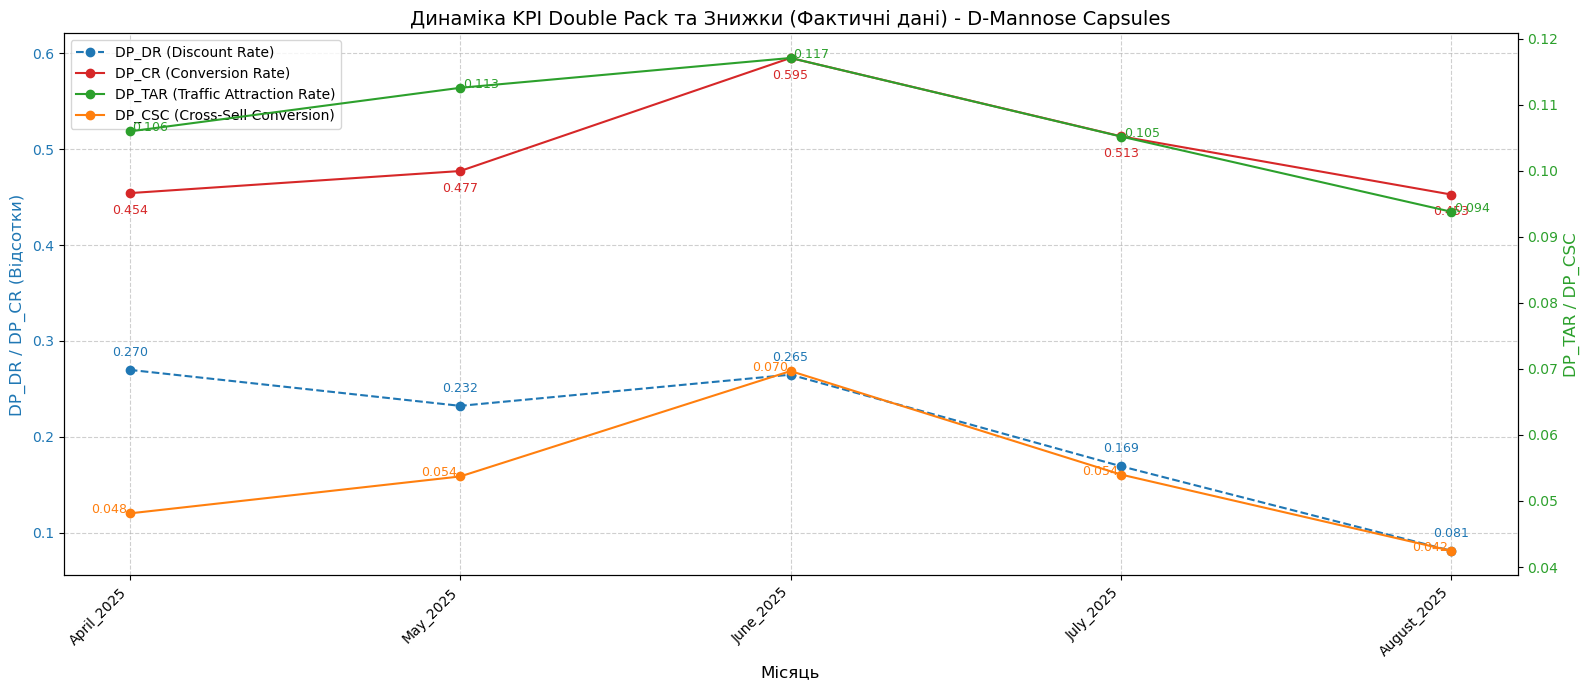


[ЗБЕРЕЖЕННЯ]: Дані KPI для 'D-Mannose Capsules' збережено у ALL_PRODUCTS_KPI.


In [7]:
# --- Розрахунок KPI та Аналіз Кореляції ---

# Примітка: Вважається, що змінні df_comparison_pivot, product_name та функція create_sort_key

# 1. Підготовка даних
df_kpi = df_comparison_pivot.copy()

# 2. Створення DataFrame для розрахунків KPI (Місяці як індекс)
metrics_for_calc = ['Sessions', 'Units Ordered', 'Actual Price']
df_calc = df_kpi.loc[metrics_for_calc].T.copy()
df_calc.index.names = ['Month_Year', 'Pack_Type']

# Розділяємо дані по паках для легшого доступу
df_sp = df_calc[df_calc.index.get_level_values('Pack_Type') == 'Single Pack'].droplevel('Pack_Type')
df_dp = df_calc[df_calc.index.get_level_values('Pack_Type') == 'Double Pack'].droplevel('Pack_Type')

# Об'єднуємо обидва DF за місяцями
df_raw = df_sp.join(df_dp, lsuffix='_SP', rsuffix='_DP')


# 3. Розрахунок KPI (помісячно)

# 3.1. Розрахунок DP_DR (Discount Rate - Відсоток Знижки)
df_raw['DP_DR'] = 1 - (df_raw['Actual Price_DP'] / (df_raw['Actual Price_SP'] * 2))

# 3.2. Розрахунок DP_CR (Conversion Rate - Конверсія продажів Double Pack)
df_raw['DP_CR'] = df_raw['Units Ordered_DP'] / df_raw['Sessions_DP']

# 3.3. Розрахунок DP_TAR (Traffic Attraction Rate - Конверсія залученості Double Pack)
df_raw['DP_TAR'] = df_raw['Sessions_DP'] / df_raw['Sessions_SP']

# 3.4. Розрахунок DP_CSC (Cross-Sell Conversion - Крос-продажна конверсія)
df_raw['DP_CSC'] = df_raw['Units Ordered_DP'] / df_raw['Sessions_SP']

# 4. Створення фінального DataFrame з KPI
df_kpi_calculated = df_raw[['DP_DR', 'DP_CR', 'DP_TAR', 'DP_CSC']].copy()

# Транспонуємо для формату: Метрики (рядки) x Місяці (колонки)
df_kpi_pivot = df_kpi_calculated.T

# Забезпечуємо правильний порядок рядків
kpi_order = ['DP_DR', 'DP_CR', 'DP_TAR', 'DP_CSC']
df_kpi_pivot = df_kpi_pivot.reindex(kpi_order)


# --- 5. РОЗРАХУНОК ТА ВИВЕДЕННЯ КОЕФІЦІЄНТІВ КОРЕЛЯЦІЇ ---

# Розраховуємо кореляцію DP_DR з іншими показниками
corr_cr = df_kpi_calculated['DP_CR'].corr(df_kpi_calculated['DP_DR'])
corr_tar = df_kpi_calculated['DP_TAR'].corr(df_kpi_calculated['DP_DR'])
corr_csc = df_kpi_calculated['DP_CSC'].corr(df_kpi_calculated['DP_DR'])

print("\n--- СЕРВІСНА ІНФОРМАЦІЯ: Коефіцієнти Кореляції ---")
print(f"Коефіцієнт DP_CR та DP_DR кореляції: {corr_cr:.4f}")
print(f"Коефіцієнт DP_TAR та DP_DR кореляції: {corr_tar:.4f}")
print(f"Коефіцієнт DP_CSC та DP_DR кореляції: {corr_csc:.4f}")
print("-" * 50)


# --- 6. ВИВЕДЕННЯ ЗВЕДЕНОЇ ТАБЛИЦІ KPI ---

print("\n--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---")
df_kpi_styled = df_kpi_pivot.style.format('{:.4f}')
display(df_kpi_styled)


# --- 7. БУДУВАННЯ СПІЛЬНОГО ЛІНІЙНОГО ГРАФІКА (З ПОКРАЩЕННЯМИ) ---

# Використовуємо df_kpi_calculated (фактичні значення, Місяці - індекс)
df_plot = df_kpi_calculated.copy()

# Налаштування графіка
fig, ax1 = plt.subplots(figsize=(16, 7))

# Визначення кольорів
colors = {'DP_DR': 'tab:blue', 'DP_CR': 'tab:red', 'DP_TAR': 'tab:green', 'DP_CSC': 'tab:orange'}
line_styles = {'DP_DR': '--', 'DP_CR': '-', 'DP_TAR': '-', 'DP_CSC': '-'}
markers = 'o'
font_size_labels = 9

# --- ЛІВА ВІСЬ (AX1): DP_DR та DP_CR (Відсотки) ---
ax1.set_xlabel('Місяць', fontsize=12)
ax1.set_ylabel('DP_DR / DP_CR (Відсотки)', color=colors['DP_DR'], fontsize=12)
ax1.tick_params(axis='y', labelcolor=colors['DP_DR'])
ax1.grid(True, linestyle='--', alpha=0.6)

# Побудова DP_DR (пунктирна лінія)
p1 = ax1.plot(df_plot.index, df_plot['DP_DR'], label='DP_DR (Discount Rate)', color=colors['DP_DR'], 
              linestyle=line_styles['DP_DR'], marker=markers)

# Побудова DP_CR (суцільна лінія)
p2 = ax1.plot(df_plot.index, df_plot['DP_CR'], label='DP_CR (Conversion Rate)', color=colors['DP_CR'], 
              linestyle=line_styles['DP_CR'], marker=markers)

# Додавання підписів DP_DR та DP_CR
for i, month in enumerate(df_plot.index):
    # DP_DR
    ax1.annotate(f"{df_plot['DP_DR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_DR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_DR'])
    # DP_CR
    ax1.annotate(f"{df_plot['DP_CR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_CR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(0,-15), 
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_CR'])


# --- ПРАВА ВІСЬ (AX2): DP_TAR та DP_CSC ---
ax2 = ax1.twinx()
ax2.set_ylabel('DP_TAR / DP_CSC', color=colors['DP_TAR'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=colors['DP_TAR'])

# Побудова DP_TAR
p3 = ax2.plot(df_plot.index, df_plot['DP_TAR'], label='DP_TAR (Traffic Attraction Rate)', color=colors['DP_TAR'], 
              linestyle=line_styles['DP_TAR'], marker=markers)

# Побудова DP_CSC
p4 = ax2.plot(df_plot.index, df_plot['DP_CSC'], label='DP_CSC (Cross-Sell Conversion)', color=colors['DP_CSC'], 
              linestyle=line_styles['DP_CSC'], marker=markers)

# Додавання підписів DP_TAR та DP_CSC
for i, month in enumerate(df_plot.index):
    # DP_TAR
    ax2.annotate(f"{df_plot['DP_TAR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_TAR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(15, 0), # Зміщено праворуч
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_TAR'])
    # DP_CSC
    ax2.annotate(f"{df_plot['DP_CSC'].iloc[i]:.3f}", 
                 (month, df_plot['DP_CSC'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(-15, 0), # Зміщено ліворуч
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_CSC'])


# --- Фінальні налаштування ---
plt.title(f'Динаміка KPI Double Pack та Знижки (Фактичні дані) - {product_name}', fontsize=14)
ax1.set_xticks(df_plot.index)
ax1.set_xticklabels(df_plot.index, rotation=45, ha='right')

# Об'єднання легенд
lines = p1 + p2 + p3 + p4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.8)

fig.tight_layout()
plt.show()

# Запис даних для виведення в загальні графіки
ALL_PRODUCTS_KPI[product_name] = df_kpi_calculated
print(f"\n[ЗБЕРЕЖЕННЯ]: Дані KPI для '{product_name}' збережено у ALL_PRODUCTS_KPI.")

### ПРОДУКТ: Mg Glycinate Capsules
### КРОК 4.1: Агрегація та консолідація історичних даних

In [8]:
# ⚠️ ЗМІННІ ДЛЯ РУЧНОЇ ЗМІНИ
# ----------------------------------------------------------------------------------------------------------------------
product_name = 'Mg Glycinate Capsules' 
product_dir = '/Users/radyslav/data_analysis/Amazon/prod_perc_dpack/Mg Glycinate Capsules' # Повний шлях до директорії
# ----------------------------------------------------------------------------------------------------------------------

# Визначаємо кореневу директорію та назву файлу констант
root_dir = os.path.dirname(product_dir)
costs_file_name = 'Product Cost Info.xlsx'
costs_file_path = os.path.join(root_dir, costs_file_name)

# Визначаємо базову назву продукту для фільтрації констант
base_product_name = product_name.replace(' Capsules', '').replace('(Stable Price)', '').strip()


# --- 2. ФУНКЦІЇ ДЛЯ ОБРОБКИ ДАНИХ ---

def get_product_unit_economics(file_path, base_name):
    """Витягує фінансові константи (COGS, FBA Fee, Ref Fee Rate, ASIN)."""
    try:
        df_costs = pd.read_excel(file_path, header=0)
    except FileNotFoundError:
        print(f"Помилка: Файл собівартості не знайдено за шляхом: {file_path}")
        return {}
    
    # Очищення та фільтрація
    df_costs.columns = df_costs.columns.str.strip().str.lower().str.replace(' ', '_')
    df_costs = df_costs.dropna(subset=['short_product_name']).reset_index(drop=True)

    df_product_group = df_costs[df_costs['short_product_name'].str.contains(base_name, case=False, na=False)].copy()

    if df_product_group.empty: return {}

    # Ідентифікація паків за кількістю одиниць
    df_product_group['unit_count'] = df_product_group['short_product_name'].str.extract(r'(\d+)').astype(float)
    df_product_group = df_product_group.dropna(subset=['unit_count'])
    if len(df_product_group) < 2: return {}

    idx_dp = df_product_group['unit_count'].idxmax()
    idx_sp = df_product_group['unit_count'].idxmin()

    results_raw = {'Single Pack': df_product_group.loc[idx_sp], 'Double Pack': df_product_group.loc[idx_dp]}
    unit_economics_final = {}
    
    # Очищення та перетворення констант
    for pack_type, data in results_raw.items():
        costs = {}
        for col in ['cogs', 'fba_fee']:
            raw_value = str(data.get(col, 0))
            cleaned_value = raw_value.strip().replace('$', '').replace(',', '')
            costs[col] = pd.to_numeric(cleaned_value, errors='coerce') 

        raw_ref_fee = str(data.get('ref_fee', '0%'))
        if '%' in raw_ref_fee:
              ref_fee_rate = pd.to_numeric(raw_ref_fee.strip().replace('%', ''), errors='coerce') / 100
        else:
              numeric_val = pd.to_numeric(raw_ref_fee, errors='coerce')
              ref_fee_rate = numeric_val / 100 if numeric_val > 1 else numeric_val

        costs['ref_fee_rate'] = ref_fee_rate
        costs['asin'] = data['asin'] 
        unit_economics_final[pack_type] = costs

    return unit_economics_final

def process_single_csv(file_path, file_name, current_asin):
    """Обробляє один CSV-файл, об'єднує Total/B2B метрики та витягує дату."""
    try:
        df = pd.read_csv(file_path, header=0, encoding='utf-8')
    except Exception as e:
        print(f"Помилка зчитування файлу {file_name}: {e}")
        return None, 0

    cols_mapping = {
        'Sessions': ['Sessions - Total', 'Sessions - Total - B2B'],
        'Units Ordered': ['Units Ordered', 'Units Ordered - B2B'],
        'Ordered Product Sales': ['Ordered Product Sales', 'Ordered Product Sales - B2B']
    }
    
    monthly_data = {'ASIN': current_asin}
    
    for new_col, raw_cols in cols_mapping.items():
        temp_df = df[raw_cols].copy()
        for col in raw_cols:
            if temp_df[col].dtype == object: 
                temp_df[col] = temp_df[col].astype(str).str.replace(r'[\$,\s]', '', regex=True)
            temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
        
        total_sum = temp_df.sum().sum() 
        monthly_data[new_col] = total_sum

    date_match = re.search(r'([A-Za-z]+_\d{4})', file_name)
    monthly_data['Month_Year'] = date_match.group(1) if date_match else "Unknown_Date"

    return pd.DataFrame([monthly_data]), len(df)

def create_sort_key(month_year_str):
    """Створює ключ сортування datetime для Month_Year."""
    if '_' in month_year_str:
        date_str = month_year_str.replace('_', ' ')
        try:
            return pd.to_datetime(date_str, format='%B %Y') 
        except ValueError:
            return pd.NaT 
    return pd.NaT


# --- 3. ДИНАМІЧНИЙ ПОШУК ПАКІВ ТА ПІДГОТОВКА ---

if not os.path.isdir(product_dir):
    raise FileNotFoundError(f"Помилка: Директорія продукту '{product_dir}' не знайдена.")

all_items = os.listdir(product_dir)
single_pack_folder = next((item for item in all_items if "single pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)
double_pack_folder = next((item for item in all_items if "double pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)

if not single_pack_folder or not double_pack_folder:
      raise FileNotFoundError("Помилка: Не знайдено підпапок 'Single Pack' або 'Double Pack'.")

single_pack_dir = os.path.join(product_dir, single_pack_folder)
double_pack_dir = os.path.join(product_dir, double_pack_folder)

pack_dirs = {'Single Pack': single_pack_dir, 'Double Pack': double_pack_dir}

def count_csv_files(directory):
    if not os.path.isdir(directory): return 0, []
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    return len(csv_files), csv_files 
_, single_files_list = count_csv_files(single_pack_dir)
_, double_files_list = count_csv_files(double_pack_dir)
pack_files = {'Single Pack': single_files_list, 'Double Pack': double_files_list}

unit_economics = get_product_unit_economics(costs_file_path, base_product_name)

# Змінні для Сервісної Інформації
total_rows_sp = 0
total_rows_dp = 0


# --- 4. АГРЕГАЦІЯ, KPI ТА ФІНАЛІЗАЦІЯ: SINGLE PACK ---
pack_type = 'Single Pack'
asin_sp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

single_pack_data = []
for file_name in pack_files[pack_type]:
    df_month, rows_count = process_single_csv(os.path.join(pack_dirs[pack_type], file_name), file_name, asin_sp)
    if df_month is not None: 
        single_pack_data.append(df_month)
        total_rows_sp += rows_count # Додавання оброблених рядків

df_single_raw = pd.concat(single_pack_data, ignore_index=True)
df_single_raw['Date_Sort'] = df_single_raw['Month_Year'].apply(create_sort_key)
df_single_kpi = df_single_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# Розрахунок Фінансових Метрик (Net Profit)
if unit_economics and pack_type in unit_economics:
    cogs = unit_economics[pack_type]['cogs']
    fba_fee = unit_economics[pack_type]['fba_fee']
    ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']
    
    df_single_kpi['Product Costs'] = (df_single_kpi['Units Ordered'] * (cogs + fba_fee)) + \
                                     (df_single_kpi['Ordered Product Sales'] * ref_fee_rate)
    
    df_single_kpi['Net Profit'] = df_single_kpi['Ordered Product Sales'] - df_single_kpi['Product Costs']
else:
    cogs = np.nan 
    fba_fee = np.nan 
    ref_fee_rate = np.nan 
    df_single_kpi['Product Costs'] = np.nan
    df_single_kpi['Net Profit'] = np.nan

# Розрахунок Actual Price
df_single_kpi['Actual Price'] = df_single_kpi['Ordered Product Sales'] / df_single_kpi['Units Ordered']
    
# Змінні для Сервісної Інформації (Single Pack)
sp_consts_info = f"COGS: {cogs:.2f}, FBA Fee: {fba_fee:.2f}, Ref Rate: {ref_fee_rate:.2%}"

# Створення Фінального Датасету для Single Pack
final_cols_sp = ['Month_Year', 'Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price', 'Date_Sort']
df_single_final = df_single_kpi[final_cols_sp].copy()
months_single_all = set(df_single_final['Month_Year'].unique()) # Всі місяці SP


# --- 5. АГРЕГАЦІЯ, KPI ТА ФІНАЛІЗАЦІЯ: DOUBLE PACK ---
pack_type = 'Double Pack'
asin_dp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

double_pack_data = []
for file_name in pack_files[pack_type]:
    df_month, rows_count = process_single_csv(os.path.join(pack_dirs[pack_type], file_name), file_name, asin_dp)
    if df_month is not None: 
        double_pack_data.append(df_month)
        total_rows_dp += rows_count # Додавання оброблених рядків

df_double_raw = pd.concat(double_pack_data, ignore_index=True)
df_double_raw['Date_Sort'] = df_double_raw['Month_Year'].apply(create_sort_key)
df_double_kpi = df_double_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# Розрахунок Фінансових Метрик (Net Profit)
if unit_economics and pack_type in unit_economics:
    cogs = unit_economics[pack_type]['cogs']
    fba_fee = unit_economics[pack_type]['fba_fee']
    ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']
    
    df_double_kpi['Product Costs'] = (df_double_kpi['Units Ordered'] * (cogs + fba_fee)) + \
                                     (df_double_kpi['Ordered Product Sales'] * ref_fee_rate)
    
    df_double_kpi['Net Profit'] = df_double_kpi['Ordered Product Sales'] - df_double_kpi['Product Costs']
else:
    cogs = np.nan 
    fba_fee = np.nan 
    ref_fee_rate = np.nan 
    df_double_kpi['Product Costs'] = np.nan
    df_double_kpi['Net Profit'] = np.nan

# Розрахунок Actual Price
df_double_kpi['Actual Price'] = df_double_kpi['Ordered Product Sales'] / df_double_kpi['Units Ordered']

# Змінні для Сервісної Інформації (Double Pack)
dp_consts_info = f"COGS: {cogs:.2f}, FBA Fee: {fba_fee:.2f}, Ref Rate: {ref_fee_rate:.2%}"

# Створення Фінального Датасету для Double Pack
df_double_final = df_double_kpi[final_cols_sp].copy()
months_double_all = set(df_double_final['Month_Year'].unique()) # Всі місяці DP


# --- 6. СЕРВІСНА ІНФОРМАЦІЯ ТА ФІНАЛЬНИЙ ВИВІД ---

# 6.1: КОНСОЛІДАЦІЯ ТА ПІДГОТОВКА ДО ВИВОДУ
months_single = set(df_single_final['Month_Year'].unique())
months_double = set(df_double_final['Month_Year'].unique())
common_months = sorted(list(months_single.intersection(months_double)), key=create_sort_key)
pack_type_order = ['Single Pack', 'Double Pack']

# Визначення не спільних місяців
non_common_months = (months_single_all.difference(common_months)).union(months_double_all.difference(common_months))
non_common_months_list = sorted(list(non_common_months), key=create_sort_key)
non_common_months_output = ', '.join(non_common_months_list) if non_common_months_list else "Всі місяці співпали"


# 6.2: ДРУК СЕРВІСНОЇ ІНФОРМАЦІЇ
print(f"\n--- СЕРВІСНА ІНФОРМАЦІЯ ДЛЯ ЗВІРКИ ---")
print(f"Аналізований Продукт: {product_name}")
print(f"Назва продукту: {base_product_name}")
print(f"Коренева директорія продукту: {root_dir}")
print("-" * 50)

print(f"Шлях Single Pack: {single_pack_dir}")
print(f"ASIN Single Pack: {asin_sp}")
print(f"Кількість файлів Single Pack: {len(pack_files['Single Pack'])}")
print(f"Кількість рядків, оброблених по всім CSV, Single Pack: {total_rows_sp}")
print(f"Показники констант юніт економіки Single Pack: {sp_consts_info}")
print("-" * 50)

print(f"Шлях Double Pack: {double_pack_dir}")
print(f"ASIN Double Pack: {asin_dp}")
print(f"Кількість файлів Double Pack: {len(pack_files['Double Pack'])}")
print(f"Кількість рядків, оброблених по всім CSV, Double Pack: {total_rows_dp}")
print(f"Показники констант юніт економіки Double Pack: {dp_consts_info}")
print("-" * 50)

print(f"Місяці, що не є спільними для Single Pack та Double Pack: {non_common_months_output}")
print("-" * 50)


# 6.3: СТВОРЕННЯ ЄДИНОГО ПОРІВНЯЛЬНОГО ДАТАСЕТУ
if not common_months:
    print("❌ Помилка: Спільних місяців для порівняння не знайдено. Фінальна таблиця порожня.")
    df_comparison_pivot = pd.DataFrame() 
else:
    # Об'єднання та Фільтрація
    df_single_combined = df_single_final.assign(Pack_Type='Single Pack')
    df_double_combined = df_double_final.assign(Pack_Type='Double Pack')
    df_combined = pd.concat([df_single_combined, df_double_combined], ignore_index=True)
    df_combined_filtered = df_combined[df_combined['Month_Year'].isin(common_months)].copy()

    # Трансформація: Melt та Pivot
    df_combined_filtered['Pack_Type'] = pd.Categorical(df_combined_filtered['Pack_Type'], categories=pack_type_order, ordered=True)
    comparison_values = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price']

    df_for_pivot = df_combined_filtered[['Month_Year', 'Pack_Type'] + comparison_values].melt(
        id_vars=['Month_Year', 'Pack_Type'],
        value_vars=comparison_values,
        var_name='Metric',
        value_name='Value'
    )
    
    # Сортування перед Pivot
    df_for_pivot['Date_Sort'] = df_for_pivot['Month_Year'].apply(create_sort_key)
    df_for_pivot = df_for_pivot.sort_values(by=['Date_Sort', 'Pack_Type']).drop(columns=['Date_Sort'])
    
    # Фінальний Pivot
    df_comparison_pivot = df_for_pivot.pivot_table(
        index='Metric', 
        columns=['Month_Year', 'Pack_Type'], 
        values='Value',
        aggfunc='sum',
        observed=False 
    )

    # Сортування Колонок та Рядків
    sorted_cols = []
    for month in common_months:
        for pack in pack_type_order:
            sorted_cols.append((month, pack))

    df_comparison_pivot = df_comparison_pivot[sorted_cols]
    df_comparison_pivot.columns.names = ['Month_Year', 'Pack_Type']
    
    # Сортування рядків з додаванням 'Actual Price'
    row_order_final = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 'Actual Price']
    df_comparison_pivot = df_comparison_pivot.reindex(row_order_final)
    
    
    # 6.4: Виведення Результату
    print("\n--- ЗВЕДЕНА ТАБЛИЦЯ: Історичні Показники SP vs DP ---")
    
    # Форматування виводу: {:.2f} (float64 без роздільників розрядів)
    df_comparison_pivot_styled = df_comparison_pivot.style.format('{:.2f}')
    display(df_comparison_pivot_styled)


--- СЕРВІСНА ІНФОРМАЦІЯ ДЛЯ ЗВІРКИ ---
Аналізований Продукт: Mg Glycinate Capsules
Назва продукту: Mg Glycinate
Коренева директорія продукту: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack
--------------------------------------------------
Шлях Single Pack: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack/Mg Glycinate Capsules/Mg Glycinate 120 Capsules (Single Pack)
ASIN Single Pack: B0BXYDMKVG
Кількість файлів Single Pack: 11
Кількість рядків, оброблених по всім CSV, Single Pack: 19
Показники констант юніт економіки Single Pack: COGS: 3.52, FBA Fee: 3.68, Ref Rate: 15.00%
--------------------------------------------------
Шлях Double Pack: /Users/radyslav/data_analysis/Amazon/prod_perc_dpack/Mg Glycinate Capsules/Mg Glycinate 240 Capsules (Double Pack)
ASIN Double Pack: B0DFCZVLMB
Кількість файлів Double Pack: 10
Кількість рядків, оброблених по всім CSV, Double Pack: 15
Показники констант юніт економіки Double Pack: COGS: 6.31, FBA Fee: 4.15, Ref Rate: 15.00%
--------------

### ПРОДУКТ: Mg Glycinate Capsules
### КРОК 4.2: Розрахунок KPI, аналіз кореляції, побудова зведеного графіку


--- СЕРВІСНА ІНФОРМАЦІЯ: Коефіцієнти Кореляції (КРОК 1.2) ---
Коефіцієнт DP_CR та DP_DR кореляції: 0.8218
Коефіцієнт DP_TAR та DP_DR кореляції: 0.3350
Коефіцієнт DP_CSC та DP_DR кореляції: 0.4240
--------------------------------------------------

--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---


Month_Year,November_2024,December_2024,January_2025,February_2025,March_2025,April_2025,May_2025,June_2025,July_2025,August_2025
Metric,,,,,,,,,,
DP_DR,0.0261,0.1134,0.1781,0.1911,0.1577,0.1519,0.1267,0.1212,0.2470,0.2259
DP_CR,0.1776,0.3087,0.3227,0.3368,0.3256,0.3322,0.3099,0.3144,0.3301,0.3402
DP_TAR,0.0168,0.0739,0.0649,0.0024,0.0782,0.0461,0.0746,0.0604,0.0732,0.0774
DP_CSC,0.0030,0.0228,0.0209,0.0008,0.0255,0.0153,0.0231,0.0190,0.0242,0.0263


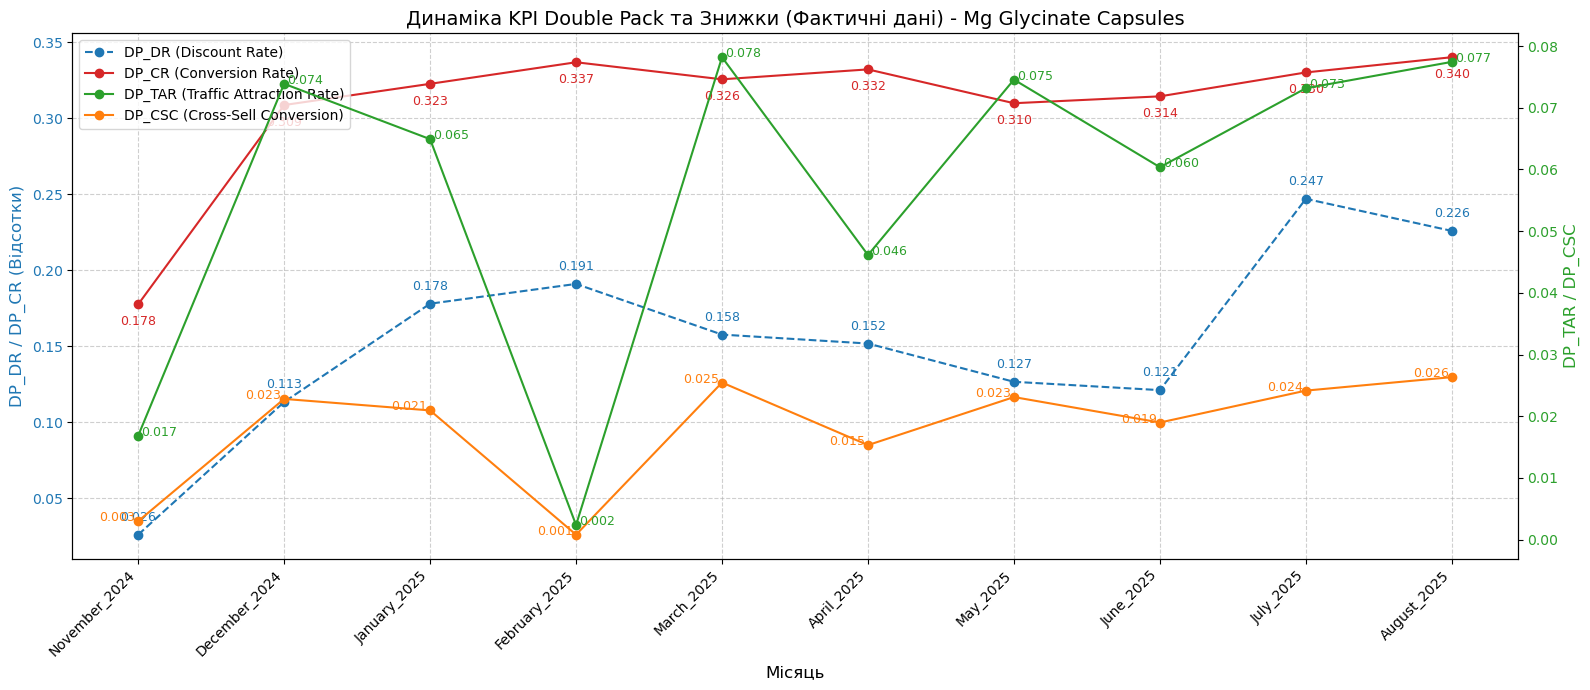


[ЗБЕРЕЖЕННЯ]: Дані KPI для 'Mg Glycinate Capsules' збережено у ALL_PRODUCTS_KPI.


In [9]:
# --- Розрахунок KPI та Аналіз Кореляції ---

# Примітка: Вважається, що змінні df_comparison_pivot, product_name та функція create_sort_key

# 1. Підготовка даних
df_kpi = df_comparison_pivot.copy()

# 2. Створення DataFrame для розрахунків KPI (Місяці як індекс)
metrics_for_calc = ['Sessions', 'Units Ordered', 'Actual Price']
df_calc = df_kpi.loc[metrics_for_calc].T.copy()
df_calc.index.names = ['Month_Year', 'Pack_Type']

# Розділяємо дані по паках для легшого доступу
df_sp = df_calc[df_calc.index.get_level_values('Pack_Type') == 'Single Pack'].droplevel('Pack_Type')
df_dp = df_calc[df_calc.index.get_level_values('Pack_Type') == 'Double Pack'].droplevel('Pack_Type')

# Об'єднуємо обидва DF за місяцями
df_raw = df_sp.join(df_dp, lsuffix='_SP', rsuffix='_DP')


# 3. Розрахунок KPI (помісячно)

# 3.1. Розрахунок DP_DR (Discount Rate - Відсоток Знижки)
df_raw['DP_DR'] = 1 - (df_raw['Actual Price_DP'] / (df_raw['Actual Price_SP'] * 2))

# 3.2. Розрахунок DP_CR (Conversion Rate - Конверсія продажів Double Pack)
df_raw['DP_CR'] = df_raw['Units Ordered_DP'] / df_raw['Sessions_DP']

# 3.3. Розрахунок DP_TAR (Traffic Attraction Rate - Конверсія залученості Double Pack)
df_raw['DP_TAR'] = df_raw['Sessions_DP'] / df_raw['Sessions_SP']

# 3.4. Розрахунок DP_CSC (Cross-Sell Conversion - Крос-продажна конверсія)
df_raw['DP_CSC'] = df_raw['Units Ordered_DP'] / df_raw['Sessions_SP']

# 4. Створення фінального DataFrame з KPI
df_kpi_calculated = df_raw[['DP_DR', 'DP_CR', 'DP_TAR', 'DP_CSC']].copy()

# Транспонуємо для формату: Метрики (рядки) x Місяці (колонки)
df_kpi_pivot = df_kpi_calculated.T

# Забезпечуємо правильний порядок рядків
kpi_order = ['DP_DR', 'DP_CR', 'DP_TAR', 'DP_CSC']
df_kpi_pivot = df_kpi_pivot.reindex(kpi_order)


# --- 5. РОЗРАХУНОК ТА ВИВЕДЕННЯ КОЕФІЦІЄНТІВ КОРЕЛЯЦІЇ ---

# Розраховуємо кореляцію DP_DR з іншими показниками
corr_cr = df_kpi_calculated['DP_CR'].corr(df_kpi_calculated['DP_DR'])
corr_tar = df_kpi_calculated['DP_TAR'].corr(df_kpi_calculated['DP_DR'])
corr_csc = df_kpi_calculated['DP_CSC'].corr(df_kpi_calculated['DP_DR'])

print("\n--- СЕРВІСНА ІНФОРМАЦІЯ: Коефіцієнти Кореляції (КРОК 1.2) ---")
print(f"Коефіцієнт DP_CR та DP_DR кореляції: {corr_cr:.4f}")
print(f"Коефіцієнт DP_TAR та DP_DR кореляції: {corr_tar:.4f}")
print(f"Коефіцієнт DP_CSC та DP_DR кореляції: {corr_csc:.4f}")
print("-" * 50)


# --- 6. ВИВЕДЕННЯ ЗВЕДЕНОЇ ТАБЛИЦІ KPI ---

print("\n--- ЗВЕДЕНА ТАБЛИЦЯ: Помісячні KPI ---")
df_kpi_styled = df_kpi_pivot.style.format('{:.4f}')
display(df_kpi_styled)


# --- 7. БУДУВАННЯ СПІЛЬНОГО ЛІНІЙНОГО ГРАФІКА (З ПОКРАЩЕННЯМИ) ---

# Використовуємо df_kpi_calculated (фактичні значення, Місяці - індекс)
df_plot = df_kpi_calculated.copy()

# Налаштування графіка
fig, ax1 = plt.subplots(figsize=(16, 7))

# Визначення кольорів
colors = {'DP_DR': 'tab:blue', 'DP_CR': 'tab:red', 'DP_TAR': 'tab:green', 'DP_CSC': 'tab:orange'}
line_styles = {'DP_DR': '--', 'DP_CR': '-', 'DP_TAR': '-', 'DP_CSC': '-'}
markers = 'o'
font_size_labels = 9

# --- ЛІВА ВІСЬ (AX1): DP_DR та DP_CR (Відсотки) ---
ax1.set_xlabel('Місяць', fontsize=12)
ax1.set_ylabel('DP_DR / DP_CR (Відсотки)', color=colors['DP_DR'], fontsize=12)
ax1.tick_params(axis='y', labelcolor=colors['DP_DR'])
ax1.grid(True, linestyle='--', alpha=0.6)

# Побудова DP_DR (пунктирна лінія)
p1 = ax1.plot(df_plot.index, df_plot['DP_DR'], label='DP_DR (Discount Rate)', color=colors['DP_DR'], 
              linestyle=line_styles['DP_DR'], marker=markers)

# Побудова DP_CR (суцільна лінія)
p2 = ax1.plot(df_plot.index, df_plot['DP_CR'], label='DP_CR (Conversion Rate)', color=colors['DP_CR'], 
              linestyle=line_styles['DP_CR'], marker=markers)

# Додавання підписів DP_DR та DP_CR
for i, month in enumerate(df_plot.index):
    # DP_DR
    ax1.annotate(f"{df_plot['DP_DR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_DR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_DR'])
    # DP_CR
    ax1.annotate(f"{df_plot['DP_CR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_CR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(0,-15), 
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_CR'])


# --- ПРАВА ВІСЬ (AX2): DP_TAR та DP_CSC ---
ax2 = ax1.twinx()
ax2.set_ylabel('DP_TAR / DP_CSC', color=colors['DP_TAR'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=colors['DP_TAR'])

# Побудова DP_TAR
p3 = ax2.plot(df_plot.index, df_plot['DP_TAR'], label='DP_TAR (Traffic Attraction Rate)', color=colors['DP_TAR'], 
              linestyle=line_styles['DP_TAR'], marker=markers)

# Побудова DP_CSC
p4 = ax2.plot(df_plot.index, df_plot['DP_CSC'], label='DP_CSC (Cross-Sell Conversion)', color=colors['DP_CSC'], 
              linestyle=line_styles['DP_CSC'], marker=markers)

# Додавання підписів DP_TAR та DP_CSC
for i, month in enumerate(df_plot.index):
    # DP_TAR
    ax2.annotate(f"{df_plot['DP_TAR'].iloc[i]:.3f}", 
                 (month, df_plot['DP_TAR'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(15, 0), # Зміщено праворуч
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_TAR'])
    # DP_CSC
    ax2.annotate(f"{df_plot['DP_CSC'].iloc[i]:.3f}", 
                 (month, df_plot['DP_CSC'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(-15, 0), # Зміщено ліворуч
                 ha='center', 
                 fontsize=font_size_labels,
                 color=colors['DP_CSC'])


# --- Фінальні налаштування ---
plt.title(f'Динаміка KPI Double Pack та Знижки (Фактичні дані) - {product_name}', fontsize=14)
ax1.set_xticks(df_plot.index)
ax1.set_xticklabels(df_plot.index, rotation=45, ha='right')

# Об'єднання легенд
lines = p1 + p2 + p3 + p4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.8)

fig.tight_layout()
plt.show()

# Запис даних для виведення в загальні графіки
ALL_PRODUCTS_KPI[product_name] = df_kpi_calculated
print(f"\n[ЗБЕРЕЖЕННЯ]: Дані KPI для '{product_name}' збережено у ALL_PRODUCTS_KPI.")

### КРОК 5.1: Фінальне виведення графіків KPI для всіх продуктів

Цей крок є фінальною консолідацією та візуалізацією. Він перевіряє вміст глобального словника **`ALL_PRODUCTS_KPI`**, який зберігає розраховані ключові показники (KPI) з Кроків N.2 для кожного проаналізованого продукту.

Далі, для кожного продукту зі словника, послідовно відтворюється графік динаміки KPI з подвійними осями та підписами точок.

**Вивід:**
1.  **Сервісна інформація:** Список продуктів, успішно збережених у `ALL_PRODUCTS_KPI`.
2.  **Послідовність графіків:** Індивідуальний графік KPI (як у Кроці 1.2) для кожного продукту.

--- СЕРВІСНА ІНФОРМАЦІЯ ---
✅ Продукти, дані яких збережено (всього 4):
   - B-Complex Capsules
   - Cinnamon Capsules
   - D-Mannose Capsules
   - Mg Glycinate Capsules
------------------------------------------


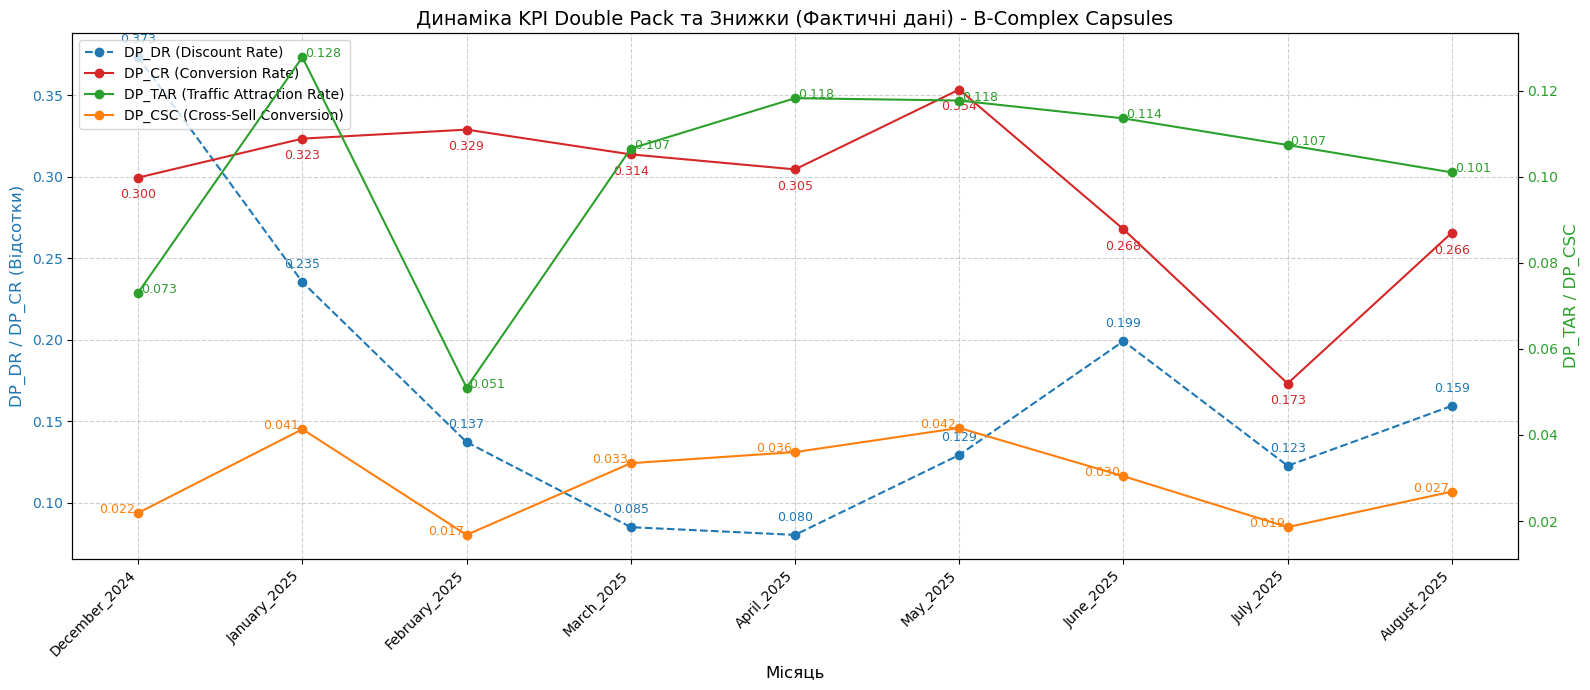

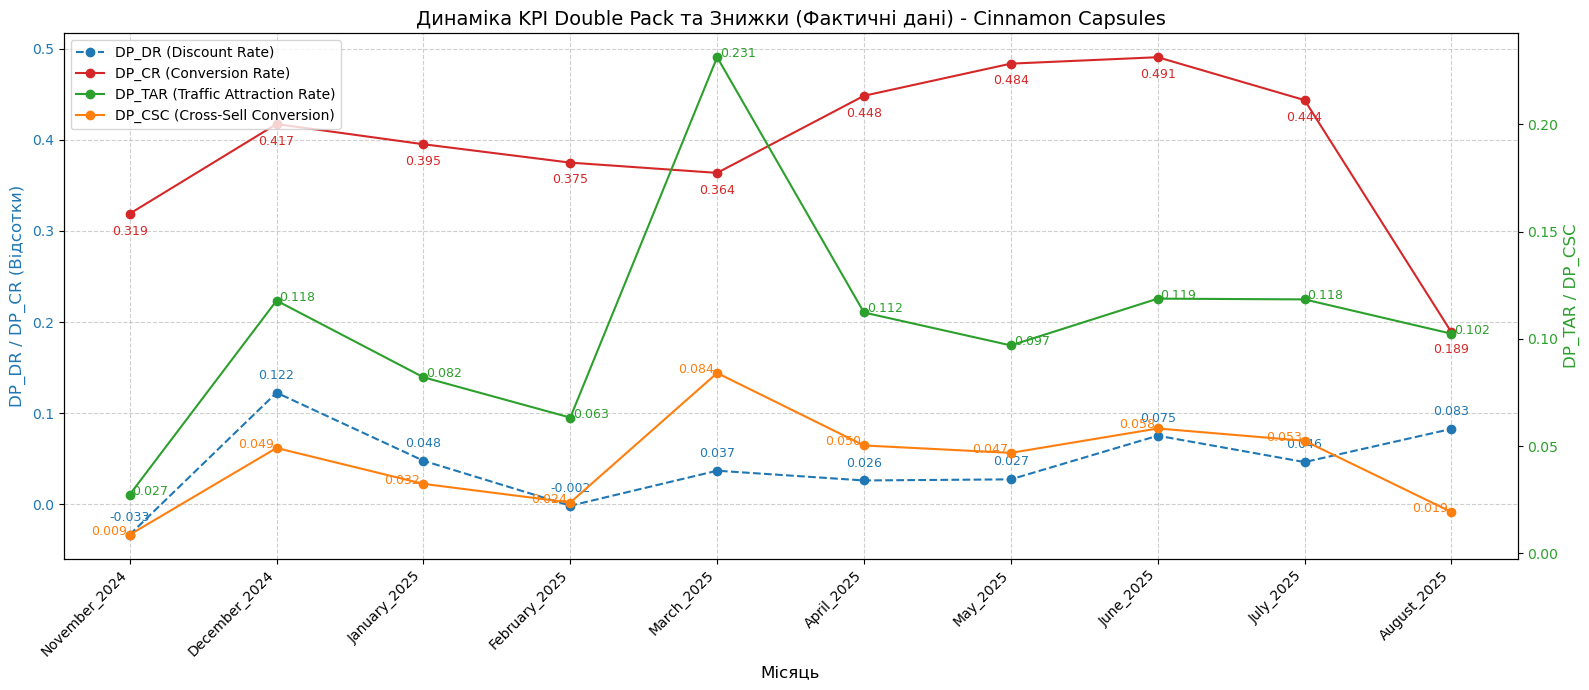

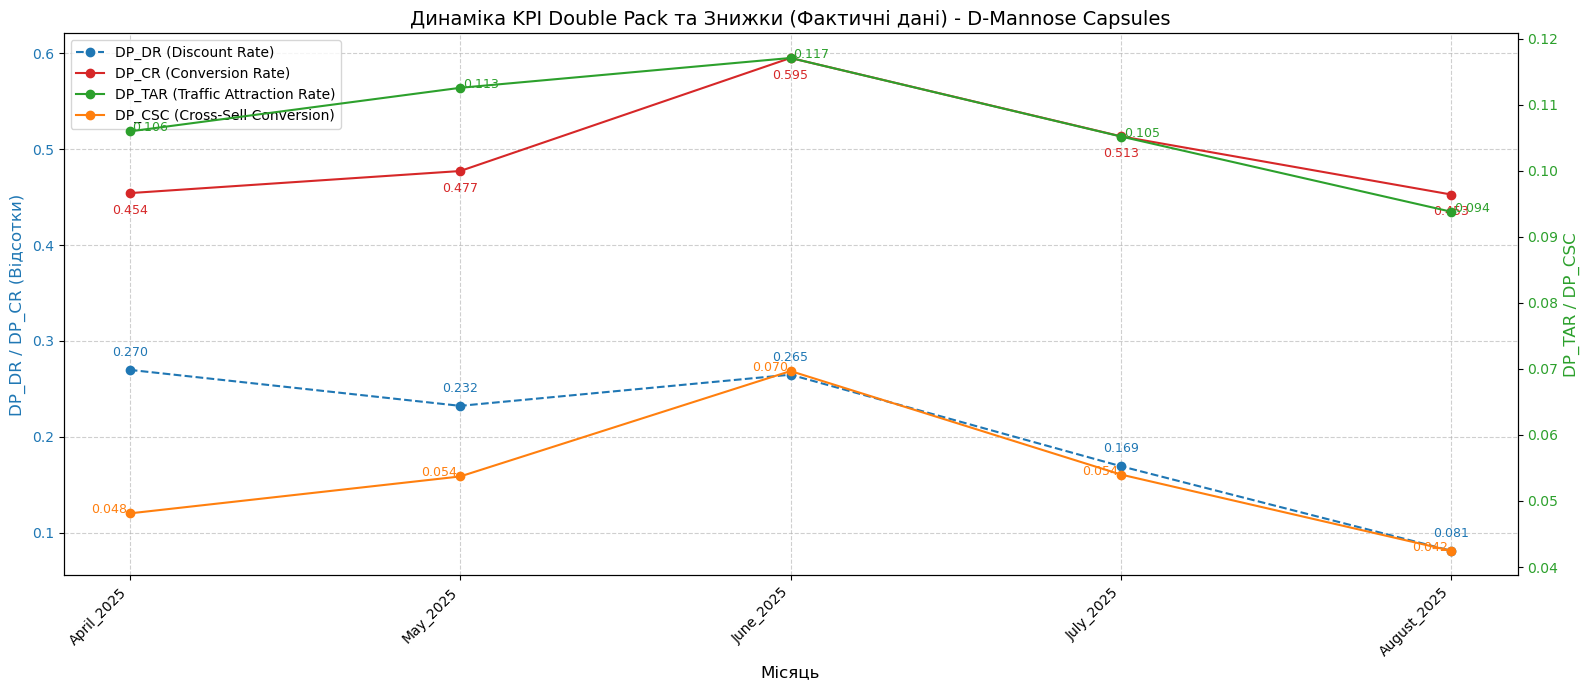

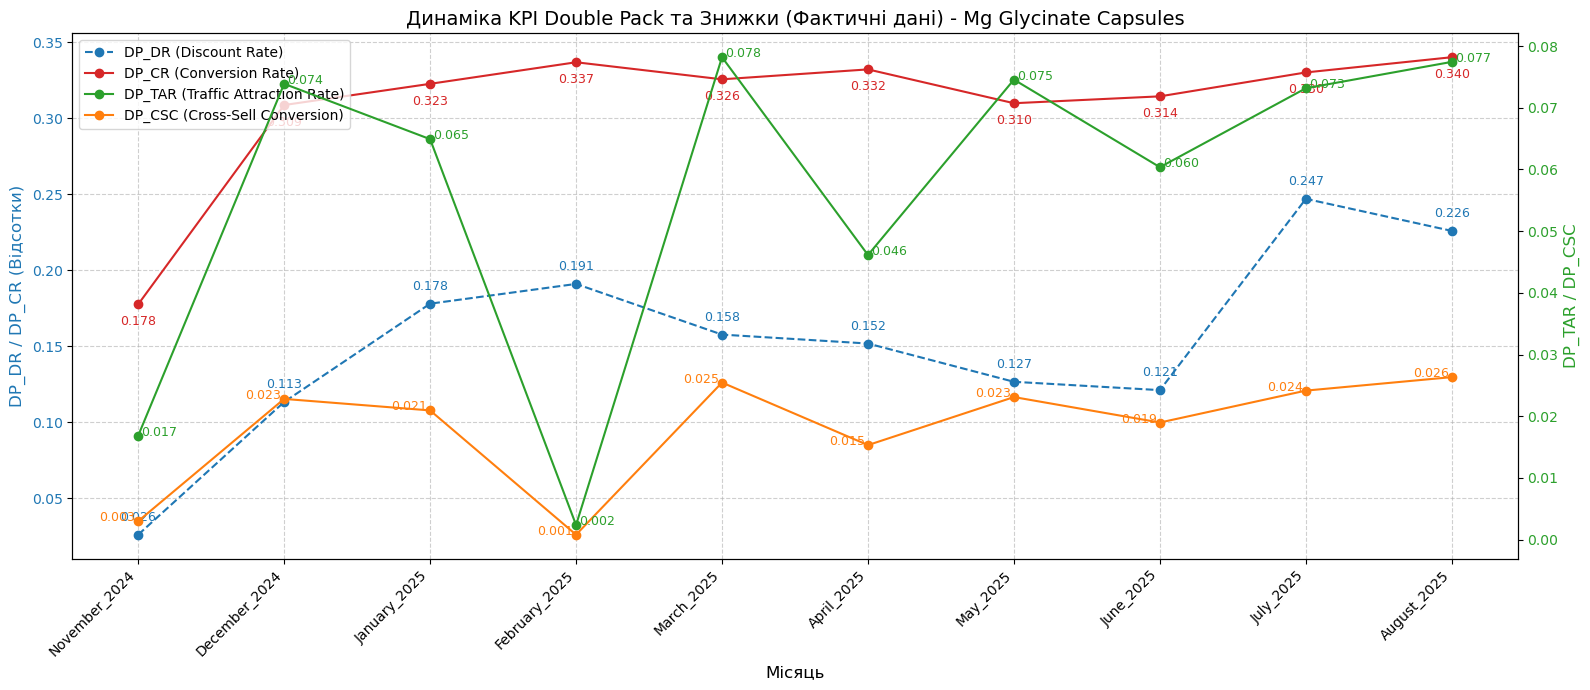

In [10]:
# --- Фінальне Виведення Індивідуальних Графіків ---

# Примітка: Вважається, що глобальний словник ALL_PRODUCTS_KPI заповнений
# даними df_kpi_calculated для всіх проаналізованих продуктів.

# --- 1. СЕРВІСНА ІНФОРМАЦІЯ ---

print("--- СЕРВІСНА ІНФОРМАЦІЯ ---")
if not ALL_PRODUCTS_KPI:
    print("❌ Помилка: Словник ALL_PRODUCTS_KPI порожній. Немає даних для побудови графіків.")
else:
    product_list = list(ALL_PRODUCTS_KPI.keys())
    print(f"✅ Продукти, дані яких збережено (всього {len(product_list)}):")
    for name in product_list:
        print(f"   - {name}")
print("------------------------------------------")


# --- 2. ФУНКЦІЯ ДЛЯ ВІДТВОРЕННЯ ГРАФІКА ---

def plot_individual_kpi(product_name, df_plot):
    
    # Налаштування графіка
    fig, ax1 = plt.subplots(figsize=(16, 7))

    # Визначення стилів (повтор стилів з Кроку 1.2)
    colors = {'DP_DR': 'tab:blue', 'DP_CR': 'tab:red', 'DP_TAR': 'tab:green', 'DP_CSC': 'tab:orange'}
    line_styles = {'DP_DR': '--', 'DP_CR': '-', 'DP_TAR': '-', 'DP_CSC': '-'}
    markers = 'o'
    font_size_labels = 9

    # --- ЛІВА ВІСЬ (AX1): DP_DR та DP_CR (Відсотки) ---
    ax1.set_xlabel('Місяць', fontsize=12)
    ax1.set_ylabel('DP_DR / DP_CR (Відсотки)', color=colors['DP_DR'], fontsize=12)
    ax1.tick_params(axis='y', labelcolor=colors['DP_DR'])
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Побудова DP_DR (пунктирна лінія)
    p1 = ax1.plot(df_plot.index, df_plot['DP_DR'], label='DP_DR (Discount Rate)', color=colors['DP_DR'], 
                  linestyle=line_styles['DP_DR'], marker=markers)

    # Побудова DP_CR (суцільна лінія)
    p2 = ax1.plot(df_plot.index, df_plot['DP_CR'], label='DP_CR (Conversion Rate)', color=colors['DP_CR'], 
                  linestyle=line_styles['DP_CR'], marker=markers)

    # Додавання підписів DP_DR та DP_CR
    for i, month in enumerate(df_plot.index):
        # DP_DR
        ax1.annotate(f"{df_plot['DP_DR'].iloc[i]:.3f}", 
                     (month, df_plot['DP_DR'].iloc[i]), 
                     textcoords="offset points", xytext=(0,10), ha='center', 
                     fontsize=font_size_labels, color=colors['DP_DR'])
        # DP_CR
        ax1.annotate(f"{df_plot['DP_CR'].iloc[i]:.3f}", 
                     (month, df_plot['DP_CR'].iloc[i]), 
                     textcoords="offset points", xytext=(0,-15), ha='center', 
                     fontsize=font_size_labels, color=colors['DP_CR'])


    # --- ПРАВА ВІСЬ (AX2): DP_TAR та DP_CSC ---
    ax2 = ax1.twinx()
    ax2.set_ylabel('DP_TAR / DP_CSC', color=colors['DP_TAR'], fontsize=12)
    ax2.tick_params(axis='y', labelcolor=colors['DP_TAR'])

    # Побудова DP_TAR
    p3 = ax2.plot(df_plot.index, df_plot['DP_TAR'], label='DP_TAR (Traffic Attraction Rate)', color=colors['DP_TAR'], 
                  linestyle=line_styles['DP_TAR'], marker=markers)

    # Побудова DP_CSC
    p4 = ax2.plot(df_plot.index, df_plot['DP_CSC'], label='DP_CSC (Cross-Sell Conversion)', color=colors['DP_CSC'], 
                  linestyle=line_styles['DP_CSC'], marker=markers)

    # Додавання підписів DP_TAR та DP_CSC
    for i, month in enumerate(df_plot.index):
        # DP_TAR
        ax2.annotate(f"{df_plot['DP_TAR'].iloc[i]:.3f}", 
                     (month, df_plot['DP_TAR'].iloc[i]), 
                     textcoords="offset points", xytext=(15, 0), ha='center', 
                     fontsize=font_size_labels, color=colors['DP_TAR'])
        # DP_CSC
        ax2.annotate(f"{df_plot['DP_CSC'].iloc[i]:.3f}", 
                     (month, df_plot['DP_CSC'].iloc[i]), 
                     textcoords="offset points", xytext=(-15, 0), ha='center', 
                     fontsize=font_size_labels, color=colors['DP_CSC'])


    # --- Фінальні налаштування ---
    ax1.set_title(f'Динаміка KPI Double Pack та Знижки (Фактичні дані) - {product_name}', fontsize=14)
    ax1.set_xticks(df_plot.index)
    ax1.set_xticklabels(df_plot.index, rotation=45, ha='right')

    # Об'єднання легенд
    lines = p1 + p2 + p3 + p4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.8)

    fig.tight_layout()
    plt.show()

# ---------------------------------------------------------------------------------
# 3. Ітерація по збережених даних та виведення графіків
# ---------------------------------------------------------------------------------

if ALL_PRODUCTS_KPI:
    for product_name, df_kpi_calculated in ALL_PRODUCTS_KPI.items():
        plot_individual_kpi(product_name, df_kpi_calculated)